&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;


# Estudo de mercado Financeiro com LSTM

Este notebook define a etapa de referência do experimento recorrente, tomando como base o histórico de preços de empresas do setor de fast-food listadas na B3 no período de 2019 a 2025.

&nbsp;&nbsp;&nbsp;&nbsp;

O intervalo é mantido integralmente, incluindo a fase mais aguda da pandemia de COVID-19, por representar uma mudança estrutural no padrão de consumo, marcada pela expansão do delivery de refeições via aplicativos, portanto, um componente relevante da dinâmica econômica desses ativos, e não apenas um ruído a ser descartado

&nbsp;&nbsp;&nbsp;&nbsp;

A escolha do recorte temporal que inclui a crise da COVID-19 é particularmente relevante para o setor de fast-food porque, nesse período, houve uma expansão sem precedentes do delivery de refeições via aplicativos, com forte crescimento tanto no volume de pedidos quanto nos gastos dos consumidores com esse tipo de serviço, o que alterou de forma estrutural os hábitos de consumo de alimentação fora do lar. Do ponto de vista de modelagem, estudos recentes que aplicam redes LSTM à previsão de séries financeiras em janelas longas que abrangem diferentes crises, incluindo a própria pandemia, mostram que o modelo é capaz de aprender o comportamento dos preços em múltiplos regimes de mercado e manter  desempenho preditivo mesmo em contextos de elevada incerteza, reforçando a pertinência de preservar esses episódios no conjunto de treinamento em vez de tratá-los como outliers a serem removidos.

&nbsp;&nbsp;&nbsp;&nbsp;

### links:

- [Entregas de comida disparam em 2020 e apps comemoram lucros](https://g1.globo.com/economia/noticia/2021/02/11/entregas-de-comida-disparam-em-2020-e-apps-comemoram-lucros.ghtml)

- [Efeito pandemia: gastos com delivery crescem 187% em 2020](https://cultura.uol.com.br/noticias/16003_efeito-pandemia-gastos-com-delivery-crescem-187-em-2020.html)

- [Financial time series prediction under Covid-19 pandemic crisis with Long Short-Term Memory (LSTM) network](https://www.nature.com/articles/s41599-023-02042-w)

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;
# <center> Objetos de estudo</center>


Estão sob análise quatro ativos do setor de alimentação/fast-food listados na B3, dos quais dois são ações locais e dois são BDRs de empresas estrangeiras.

&nbsp;&nbsp;&nbsp;&nbsp;

- **Ações locais (Brasil)**
    - **MEAL3** – International Meal Company (IMC), operadora de redes de alimentação no Brasil, incluindo marcas de fast-food como Bob’s e KFC, entre outras.
    - **ZAMP3/BKBR3** – Zamp S.A., antiga BK Brasil, responsável pela operação e franquia dos restaurantes Burger King e Popeyes no país; BKBR3 corresponde ao ticker anterior da companhia.

&nbsp;&nbsp;&nbsp;&nbsp;

- **BDRs (empresas estrangeiras listadas na B3)**
    - **MCDC34** – BDR da McDonald’s Corporation, que representa economicamente as ações da rede global de fast-food no mercado brasileiro.
    - **SBUB34** – BDR da Starbucks Corporation, que reflete o desempenho da rede global de cafeterias no pregão local.




&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

# <center>Fonte de obtenção dos dados</center>

&nbsp;&nbsp;&nbsp;&nbsp;

As séries históricas utilizadas neste estudo foram obtidas a partir de duas fontes principais de dados de mercado:

&nbsp;&nbsp;&nbsp;&nbsp;

- API `yfinance` em Python, utilizada para a extração dos dados diários de preços e volume dos ativos `MEAL3`, `SBUB34` e `MCDC34`, negociados na B3 e acessados por meio de seus respectivos tickers no Yahoo Finance.

&nbsp;&nbsp;&nbsp;&nbsp;

- Arquivos oficiais de cotações históricas da B3 (`COTAHIST_AAAA.ZIP`), disponibilizados na seção de histórico do mercado à vista, a partir dos quais foi reconstruída a série diária do ativo Burger King/Zamp.

&nbsp;&nbsp;&nbsp;&nbsp;

No caso específico de `BKBR3/ZAMP3`, ambos correspondem ao mesmo ativo ao longo do tempo, havendo apenas mudança de nome e de ticker com a transição de BK Brasil para Zamp S.A., sem quebra de continuidade econômica do papel.

Como a série deixou de estar disponível de forma completa via `yfinance`, os dados dessa ação foram consolidados diretamente a partir dos arquivos COTAHIST da B3, unificando os registros sob um ticker canônico (`ZAMP3`) e preservando o ticker original apenas para fins de rastreabilidade no pré-processamento.

&nbsp;&nbsp;&nbsp;&nbsp;

###Links

[Cotações históricas da B3](https://www.b3.com.br/pt_br/market-data-e-indices/servicos-de-dados/market-data/historico/mercado-a-vista/cotacoes-historicas/)

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

# <center>Análise de Objetos</center>


Nesta seção, analisamos separadamente cada um dos ativos selecionados, considerando seu modelo de negócio no setor de alimentação/fast-food e a situação recente de negociação na B3.

&nbsp;&nbsp;&nbsp;&nbsp;

**MEAL3 – International Meal Company (IMC)**  
A International Meal Company (IMC), negociada sob o ticker `MEAL3`, é uma operadora de serviços de alimentação com portfólio de marcas que inclui redes de fast-food e casual dining, atuando em restaurantes de estrada, aeroportos e centros urbanos, com presença relevante no mercado brasileiro.
O papel permanece listado na B3 e, apesar de períodos de resultado pressionado, segue sendo negociado normalmente, com movimentos recentes de reestruturação de portfólio e notícias sobre ajustes em marcas e operações que impactam a percepção de valor do ativo.  

&nbsp;&nbsp;&nbsp;&nbsp;

**ZAMP3/BKBR3 – Zamp S.A. (Burger King/Popeyes)**  
O ativo `ZAMP3` (antes `BKBR3`) representa a Zamp S.A., sucessora da BK Brasil, responsável pela operação e franquia de restaurantes Burger King e Popeyes no país, funcionando como um representante direto do segmento de hambúrguer e fast-food no mercado doméstico.
Em 2025, a companhia foi alvo de uma oferta pública de aquisição de ações (OPA) liderada pelo Mubadala Capital com o objetivo de fechar o capital, resultando na aquisição de uma fatia majoritária das ações em circulação e na preparação para sua deslistagem da B3, de modo que as cotações deixam de ser atualizadas no mercado após a conclusão desse processo.

&nbsp;&nbsp;&nbsp;&nbsp;

**MCDC34 – BDR McDonald’s Corporation**  
`MCDC34` é um BDR não patrocinado que representa na B3 as ações da McDonald’s Corporation, uma das maiores redes globais de fast-food, permitindo que investidores locais acompanhem o desempenho da empresa por meio de recibos negociados em reais.
O BDR permanece ativo e listado, refletindo os movimentos de preço das ações da McDonald’s no exterior, incluindo períodos de maior volatilidade associados a choques globais, mudanças de hábitos de consumo e ciclos econômicos internacionais.

&nbsp;&nbsp;&nbsp;&nbsp;

**SBUB34 – BDR Starbucks Corporation**  
`SBUB34` corresponde ao BDR da Starbucks Corporation, rede internacional de cafeterias e produtos relacionados, oferecendo exposição ao segmento de bebidas e lanches rápidos com foco em experiência de loja e consumo urbano.
Assim como outros BDRs de empresas globais de consumo, SBUB34 permanece negociado na B3, refletindo a performance das ações da Starbucks no mercado externo e incorporando tanto fatores setoriais (tendências de consumo de café e food service) quanto condições macroeconômicas globais.

&nbsp;&nbsp;&nbsp;&nbsp;

### Links:

**MEAL3 – International Meal Company (IMC)**  
- [Quem Somos – IMC (Relações com Investidores)](https://ri.internationalmealcompany.com/quem-somos)

**ZAMP3/BKBR3 – Zamp S.A.**  
- [Perfil da companhia – Zamp ON (ZAMP3)](https://br.investing.com/equities/bk-brasil-operacao-company-profile)  
- [Controladora da Zamp (ZAMP3) adquire 97,8% das ações em OPA para fechamento de capital](https://einvestidor.estadao.com.br/ultimas/zamp-zamp3-controladora-oferta-acoes-fechamento-capital-b3/)  

**MCDC34 – McDonald’s (BDR)**  
- [McDonald's MCDC34 – Cotação e indicadores](https://www.infomoney.com.br/cotacoes/b3/bdr/mc-donalds-mcdc34/)  

**SBUB34 – Starbucks (BDR)**  
- [SBUB34 – Resultados, dividendos, cotação e indicadores](https://investidor10.com.br/bdrs/sbub34/)

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

# <center>Diferença entre ações locais e BDRs</center>

&nbsp;&nbsp;&nbsp;&nbsp;

- **Ações locais (MEAL3, ZAMP3)**  
  - Você compra diretamente ações de empresas brasileiras listadas na B3.  
  - É acionista direto da companhia, com direitos políticos e econômicos previstos na legislação e no estatuto social.   
  - O risco está concentrado em fatores domésticos: economia brasileira, juros, marco regulatório e comportamento do consumidor local.   

- **BDRs (MCDC34, SBUB34)**  
  - São recibos negociados na B3 que representam ações de empresas estrangeiras mantidas em custódia no exterior.
  - Você detém o BDR em reais, mas o ativo subjacente é uma ação lá fora; a relação com a empresa é intermediada pela instituição depositária.
  - O investidor fica exposto tanto ao desempenho da empresa estrangeira quanto ao risco do país de origem e à variação cambial.


&nbsp;&nbsp;&nbsp;&nbsp;



&nbsp;&nbsp;&nbsp;&nbsp;

#<center>Como o câmbio impacta a performance de um BDR?
&nbsp;&nbsp;&nbsp;&nbsp;

O preço de um BDR em reais reflete, simultaneamente, o preço da ação no exterior e a taxa de câmbio entre o real e a moeda em que a ação é negociada (em geral, o dólar).   

&nbsp;&nbsp;&nbsp;&nbsp;

De forma simplificada, podemos pensar que:

&nbsp;&nbsp;&nbsp;&nbsp;

\begin{align}
\text{Preço do BDR (R\$)} \approx \text{Preço da ação no exterior} \times \text{câmbio (R\$/US\$)} \times \text{fator de proporção}
\end{align}

&nbsp;&nbsp;&nbsp;&nbsp;

Consequências práticas:  
- Se a ação sobe em dólar e o câmbio fica estável, o BDR tende a subir.
- Se a ação fica estável, mas o dólar se valoriza frente ao real, o BDR tende a subir apenas pelo efeito cambial.
- Se a ação cai e o dólar se desvaloriza em relação ao real, o BDR pode cair “em dobro”, pela queda do ativo e do câmbio.

&nbsp;&nbsp;&nbsp;&nbsp;

### Links:

[Qual a diferença entre Ações e BDRs? | B3](https://borainvestir.b3.com.br/tipos-de-investimentos/renda-variavel/acoes/qual-a-diferenca-entre-acoes-e-bdrs/)

[BDRs na B3: o que são e como funcionam](https://borainvestir.b3.com.br/tipos-de-investimentos/renda-variavel/bdrs/bdr-o-que-e-e-como-funciona/) [web:75]  

[BDR: 5 pontos essenciais para começar a investir | B3](https://borainvestir.b3.com.br/tipos-de-investimentos/renda-variavel/bdrs/bdr-5-pontos-essenciais-para-entender-antes-de-investir/)   

[Como a variação do dólar afeta os BDRs? | Genial Investimentos](https://suporte.genialinvestimentos.com.br/hc/pt-br/articles/6637875318036-Como-a-varia%C3%A7%C3%A3o-do-d%C3%B3lar-afeta-os-BDRs)   

[Investindo no exterior: entenda os BDRs | XP](https://conteudos.xpi.com.br/bdrs/relatorios/investindo-no-exterior-entenda-os-bdrs/)  

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

#<center> Mercado de fast-food no Brasil e sazonalidade de consumo

Para definir uma janela de contexto coerente para o modelo LSTM, é importante considerar que o consumo de fast-food no Brasil apresenta padrões sazonais bem marcados no tempo (ao longo da semana e do ano) e também mudanças estruturais recentes ligadas ao delivery.  

&nbsp;&nbsp;&nbsp;&nbsp;


### 1. Padrões de dia da semana

&nbsp;&nbsp;&nbsp;&nbsp;

Levantamentos com grandes bases de transações de alimentação fora do lar mostram que o **sábado** concentra a maior intensidade de consumo, com o maior gasto médio da semana, seguido da sexta-feira; já segunda-feira é o dia de menor desembolso.

Pesquisas de hábitos de consumo de fast-food indicam que uma parcela relevante dos brasileiros associa esse tipo de refeição a momentos de lazer, com maior frequência justamente em fins de semana, enquanto o almoço em dias úteis aparece como outro pico importante de uso.

links:  
- [Pesquisa revela que dia da semana os brasileiros comem mais fora de casa | Veja](https://veja.abril.com.br/coluna/radar/pesquisa-revela-que-dia-da-semana-os-brasileiros-comem-mais-fora-de-casa/)

- [Consumo de fast food no Brasil e suas implicações | RH Portal](https://rhportal.com.br/noticias/negocios/consumo-de-fast-food-no-brasil/)
- [Consumindo fastfood: o perfil dos brasileiros | Ecglobal](https://business.ecglobal.com/consumindo-fastfood-o-perfil-dos-brasileiros/)  
- [Um em cada dez brasileiros frequenta redes de fast-food todos os dias | InfoMoney](https://www.infomoney.com.br/consumo/um-em-cada-dez-brasileiros-frequenta-redes-de-fast-food-todos-os-dias/)  

&nbsp;&nbsp;&nbsp;&nbsp;

**Implicação para a LSTM:**  
- Vale preservar a **granularidade diária** e janelas que sejam múltiplos de ciclos semanais (por exemplo, 7, 14, 21 dias), para que o modelo consiga capturar o padrão “semana de trabalho + fim de semana” e suas repetições no preço das ações.  
- Quebras abruptas de janela que ignorem a estrutura de semana podem mascarar essa sazonalidade de demanda que se reflete no faturamento e, indiretamente, no comportamento dos ativos.  

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

### 2. Horários e ocasiões de consumo (intra-dia e rotina)

Estudos sobre alimentação fora do domicílio no Brasil apontam que o maior volume de refeições consumidas fora de casa se concentra no intervalo de **11h às 14h**, período associado ao almoço em dias úteis, seguido por janelas de tarde e início da noite, ligadas a lanches e refeições rápidas.

Pesquisas específicas com consumidores de fast-food indicam ainda que muitos enxergam esse tipo de refeição como indulgente, com forte presença em ocasiões compartilhadas com família e amigos, frequentemente no período noturno.

links:  
- [Evolução do consumo de alimentos fora do domicílio no Brasil | Rev. Saúde Pública (SciELO)](https://www.scielosp.org/article/rsp/2021.v55suppl1/6s/pt/)
- [Consumindo fastfood: o perfil dos brasileiros | Ecglobal](https://business.ecglobal.com/consumindo-fastfood-o-perfil-dos-brasileiros/) -  

&nbsp;&nbsp;&nbsp;&nbsp;


**Implicação para a LSTM:**  
- Embora o modelo trabalhe em frequência diária, esses padrões justificam tratar o ativo como ligado a **picos recorrentes de consumo em horários específicos de trabalho e lazer**, o que reforça a importância de janelas que capturem **vários ciclos de dias úteis + fim de semana**.  
- Em termos de experimentação, isso corrobora o uso de janelas de contexto que cubram pelo menos algumas semanas ou meses inteiros, em vez de recortes muito curtos, para capturar melhor a dinâmica da demanda.  

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

### 3. Tendência recente: crescimento e mudança de mix

&nbsp;&nbsp;&nbsp;&nbsp;

Relatórios recentes indicam que o consumo de fast-food no Brasil atingiu **recordes de participação no consumo fora de casa**, impulsionado por jovens, classes de maior renda e regiões metropolitanas, com crescimento em unidades para itens como hambúrguer e pizza em horizontes de médio prazo.
Esses estudos também mostram uma retomada do consumo em dias úteis, associada ao retorno do trabalho presencial e a momentos compartilhados, além de forte expansão do **delivery**, com aumento significativo de frequência e volume médio de pedidos por aplicativo.

links:  
- [Consumo de fast food atinge recorde no Brasil | Kantar](https://www.kantar.com/brazil/inspiration/consumo/2023-wp-consumo-de-fast-food-no-brasil-bra)
- [Consumo de Fast Food aumenta no Brasil no primeiro semestre | Kantar](https://www.kantar.com/brazil/inspiration/consumo/2024-wp-consumo-de-fast-food-bra)

&nbsp;&nbsp;&nbsp;&nbsp;

**Implicação para a LSTM:**  

- O recorte **2019–2025** captura: pré-pandemia, choque de COVID-19, explosão do delivery e posterior normalização com retomada do consumo fora de casa, especialmente em dias úteis.
- Em termos de janelas para LSTM, os dados de mercado sugerem que faz sentido trabalhar com janelas que sejam múltiplos de ou ciclos semanais (para capturar fins de semana) e que cubram vários meses (para capturar mudanças de regime e sazonalidade anual, como férias e feriados prolongados).  
- Assim, do ponto de vista econômico e de comportamento do consumidor, esse período oferece **riqueza de regimes e sazonalidades** suficientes para justificar um experimento de LSTM que não trate a pandemia apenas como ruído, mas como parte relevante da dinâmica de preços do setor de fast-food.  


&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;


#<center> Features </center>

&nbsp;&nbsp;&nbsp;&nbsp;

Antes do treinamento do modelo, é realizada uma etapa de engenharia de features com o objetivo de transformar a série histórica de preços, volumes e variáveis de contexto de mercado em um conjunto de atributos mais informativo para a LSTM.

&nbsp;&nbsp;&nbsp;&nbsp;

Em vez de alimentar a rede apenas com valores brutos de abertura, máxima, mínima, fechamento e volume dos ativos da carteira, foram criados indicadores que sintetizam aspectos de tendência, momento, volatilidade, comportamento de volume e influência cambial.

&nbsp;&nbsp;&nbsp;&nbsp;

A construção desses atributos busca reduzir o impacto do ruído de curtíssimo prazo e tornar mais explícitos padrões relevantes da dinâmica do mercado, evitando que a rede precise extrair essas relações exclusivamente a partir das séries brutas.

&nbsp;&nbsp;&nbsp;&nbsp;

Entre as features geradas, destacam-se:
&nbsp;&nbsp;&nbsp;&nbsp;


- médias móveis simples e exponenciais, utilizadas para capturar tendência;
- o Índice de Força Relativa (RSI), utilizado como medida de momento;
- métricas de volatilidade e amplitude intradiária, empregadas para representar risco e instabilidade recente;
- atributos ligados ao volume, como variação, média móvel e volume relativo, utilizados para indicar intensidade e possível confirmação dos movimentos de preço;
- e variáveis cambiais associadas ao comportamento do dólar (USDBRL), especialmente relevantes para as BDRs presentes na carteira, por influenciarem indiretamente o retorno desses ativos.

&nbsp;&nbsp;&nbsp;&nbsp;

Dessa forma, o dataset final passa a representar não apenas os níveis de preço observados, mas também a forma como esses preços evoluem ao longo do tempo, incorporando informações sobre força, velocidade, risco, participação do mercado e contexto cambial.

Como o objetivo do modelo não é prever o fechamento de um ativo específico, mas sim o retorno da carteira como um todo, essa etapa de engenharia de features permite que a LSTM receba uma visão mais rica dos fatores que afetam o desempenho agregado do portfólio, aumentando o potencial do modelo para identificar padrões temporais associados às variações de retorno.

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

#<center> O que representa cada feature? </center>

&nbsp;&nbsp;&nbsp;&nbsp;

### Preços e volume (OHLCV)

**O que são:**  
- `Open`, `High`, `Low`, `Close`, `Volume` (para cada ativo).  
Representam, respectivamente, preço de abertura, máxima, mínima, fechamento e volume negociado do dia.  

**Por que são relevantes:**  
- São a base de toda a análise de mercado; refletem diretamente o resultado de oferta e demanda diária.  
- A LSTM precisa desses valores para ancorar todos os demais indicadores e aprender relações entre preço, volume e retorno futuro.

OBS: As features de preço foram complementadas por versões logarítmicas do fechamento, com o objetivo de reduzir diferenças de escala entre os ativos e tornar a representação numérica mais estável para o modelo.


&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

### Médias móveis simples (SMA_14)

**O que é:**  
- `SMA_14`: média simples dos preços de fechamento dos últimos 14 pregões.  

**Relevância para o modelo:**  
- Suaviza o ruído diário e evidencia a **tendência** de curto prazo (alta, baixa ou lateral).  
- Ajuda a LSTM a distinguir movimentos pontuais de movimentos mais persistentes de preço.  

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

###  Médias móveis exponenciais (EMA_14)

**O que é:**  
- `EMA_14`: média móvel exponencial dos últimos 14 pregões, com maior peso para os dados mais recentes.  

**Relevância para o modelo:**  
- Reage mais rapidamente a mudanças de tendência do que a SMA.  
- Captura “viradas” mais recentes na dinâmica de preço, que podem ser relevantes para prever o retorno imediato.

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

###  RSI_14 (Relative Strength Index)

**O que é:**  
- `RSI_14`: indicador de momento que compara a magnitude média dos ganhos e das perdas nos últimos 14 dias.  

**Relevância para o modelo:**  
- Resume a **força compradora ou vendedora** recente em um único número.  
- LSTM pode usar o RSI para identificar períodos de forte momentum (acima ou abaixo de níveis típicos), que tendem a anteceder correções ou extensões de movimento.

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

###  Returns: Return_1d e Return_5d

**O que são:**  
- `Return_1d`: retorno percentual diário (Close_t / Close_{t-1} − 1).  
- `Return_5d`: retorno acumulado em 5 dias (Close_t / Close_{t-5} − 1).  

**Relevância para o modelo:**  
- Transformam o problema de nível de preço em variação **relativa**, mais diretamente ligada ao target de retorno.  
- `Return_1d` captura o choque de curtíssimo prazo; `Return_5d` captura movimentos mais persistentes, fornecendo múltiplas escalas de horizonte para a LSTM.  

&nbsp;&nbsp;&nbsp;&nbsp;

---

###  Volatility_10

**O que é:**  
- `Volatility_10`: desvio padrão dos retornos diários em uma janela de 10 pregões.  

**Relevância para o modelo:**  
- Mede **instabilidade recente** do ativo.  
- Períodos de alta volatilidade podem alterar a distribuição de retornos futuros e a relação risco/retorno, o que é importante para o modelo aprender regimes de mercado diferentes (tranquilo vs. turbulento).

&nbsp;&nbsp;&nbsp;&nbsp;

---

### Range

**O que é:**  
- `Range = (High − Low) / Close`: amplitude intradiária em relação ao fechamento.  

**Relevância para o modelo:**  
- Captura o “nervosismo” dentro do próprio pregão (briga entre compradores e vendedores).  
- Range alto pode sinalizar dias de maior incerteza e disputa de preço, relevantes para a dinâmica de curto prazo do retorno.  

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

### OC_Return (Open-Close Return)

**O que é:**  
- `OC_Return = (Close − Open) / Open`: retorno intradiário da abertura ao fechamento.  

**Relevância para o modelo:**  
- Mostra se o mercado passou o dia “aceitando” preços mais altos ou mais baixos em relação à abertura.  
- Ajuda a LSTM a entender o **sentimento intradiário** e a pressão direcional que pode se propagar para o dia seguinte.  

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

### Close_vs_SMA e Close_vs_EMA

**O que são:**  
- `Close_vs_SMA = Close / SMA_14 − 1`  
- `Close_vs_EMA = Close / EMA_14 − 1`  

**Relevância para o modelo:**  
- Medem o quão distante o preço está da sua tendência recente, em termos percentuais.  
- Permitem à LSTM enxergar se o ativo está “esticado” para cima ou para baixo em relação à sua própria média, algo associado a possíveis correções ou continuação de tendência.

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

### Volume_Change

**O que é:**  
- `Volume_Change = (Volume_t − Volume_{t-1}) / Volume_{t-1}`: variação percentual do volume dia a dia.  

**Relevância para o modelo:**  
- Indica se o interesse dos participantes está aumentando ou diminuindo.  
- Movimentos de preço com aumento significativo de volume tendem a ser mais “informativos” e sustentáveis.   

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

### Volume_MA_10

**O que é:**  
- `Volume_MA_10`: média móvel do volume nos últimos 10 pregões.  

**Relevância para o modelo:**  
- Suaviza ruídos de volume e fornece uma referência de “volume típico” recente.  
- Serve de base para o cálculo de volume relativo e para avaliar se a liquidez está em patamar anormal.

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

### Volume_Relative

**O que é:**  
- `Volume_Relative = Volume / Volume_MA_10`: volume atual em relação à média recente.  

**Relevância para o modelo:**  
- Indica se o dia está com **volume acima, abaixo ou próximo do normal**.  
- Ajuda o modelo a diferenciar movimentos “ociosos” de preços de movimentos acompanhados por forte participação, o que pode alterar a probabilidade de continuidade.

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

### 2.13. Features de câmbio (USDBRL_*)

**O que são:**  
- `USDBRL_Open`, `USDBRL_High`, `USDBRL_Low`, `USDBRL_Close`, mais SMA/EMA/RSI/returns/volatility análogos.  

**Relevância para o modelo:**  
- BDRs (MCDC34, SBUB34) dependem da combinação **preço da ação no exterior + câmbio**.  
- Ao incluir features de USD/BRL, a LSTM passa a enxergar choques cambiais que impactam diretamente o retorno dos BDRs, capturando melhor a dinâmica conjunta dos ativos.  

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

### 2.14. Conjunto final

**Resumo:**  
- Tendência: `SMA_14`, `EMA_14`, `Close_vs_SMA`, `Close_vs_EMA`  
- Momento: `RSI_14`, `Return_1d`, `Return_5d`  
- Volatilidade e risco: `Volatility_10`, `Range`, `OC_Return`  
- Volume: `Volume_Change`, `Volume_MA_10`, `Volume_Relative`  
- Macro de apoio: indicadores de `USDBRL`  

&nbsp;&nbsp;&nbsp;&nbsp;

Esses grupos mostram ganhos de desempenho ao combinar OHLCV com indicadores técnicos em modelos LSTM para séries financeiras, pois fornecem à rede uma visão multidimensional do comportamento dos ativos, indo além do preço em si.  

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

# <center>Por que tendências podem ser mais informativas do que preço bruto?</center>

&nbsp;&nbsp;&nbsp;&nbsp;

Como o objetivo deste trabalho não é prever o valor de fechamento de um ativo específico, mas sim modelar o **retorno da carteira**, torna-se importante refletir sobre quais representações da série temporal são mais adequadas para esse tipo de problema.

&nbsp;&nbsp;&nbsp;&nbsp;

O preço bruto de um ativo, por si só, informa apenas o **nível** em que ele se encontra em determinado instante. Embora esse valor seja importante como referência de mercado, ele nem sempre é a forma mais informativa de representar a dinâmica que interessa ao modelo quando o foco está na previsão de **variações relativas**, como os retornos.

&nbsp;&nbsp;&nbsp;&nbsp;

Isso ocorre porque o retorno está mais diretamente associado à **mudança de comportamento do preço ao longo do tempo** do que ao seu valor absoluto. Em outras palavras, para prever se a carteira tende a apresentar desempenho positivo ou negativo, costuma ser mais útil observar **como os preços estão se movendo** do que apenas onde eles estão.

&nbsp;&nbsp;&nbsp;&nbsp;

Nesse contexto, features relacionadas à tendência, como médias móveis simples e exponenciais, podem oferecer uma representação mais adequada da informação temporal. Essas variáveis suavizam oscilações de curtíssimo prazo e ajudam a destacar a direção predominante do movimento, reduzindo parte do ruído presente na série original.

&nbsp;&nbsp;&nbsp;&nbsp;

Enquanto o preço bruto pode variar de forma irregular de um pregão para outro, indicadores de tendência sintetizam o comportamento recente em uma escala mais estável, permitindo ao modelo captar com maior clareza se o ativo está em trajetória de alta, de baixa ou de lateralização. Essa distinção é relevante porque o retorno futuro tende a depender menos do preço em si e mais da **persistência, reversão ou enfraquecimento** dessa trajetória.

&nbsp;&nbsp;&nbsp;&nbsp;

Além disso, o uso de medidas de tendência ajuda a reduzir um problema comum em séries financeiras: o excesso de sensibilidade a oscilações diárias pouco informativas. Como os preços de mercado incorporam ruídos de curtíssimo prazo, notícias pontuais e flutuações intradiárias, utilizar apenas valores brutos pode dificultar a identificação de padrões temporais mais consistentes. Ao sintetizar o histórico recente, as features de tendência tornam mais explícitas relações que podem estar associadas à variação futura do retorno da carteira.

&nbsp;&nbsp;&nbsp;&nbsp;

Isso não significa que o preço bruto deva ser descartado. Pelo contrário, ele continua sendo a base a partir da qual diversas outras features são construídas. No entanto, para um problema cujo alvo está relacionado à **direção e intensidade da variação**, indicadores derivados do preço podem ser mais informativos do que o preço isolado, pois traduzem melhor o comportamento dinâmico que se deseja modelar.

&nbsp;&nbsp;&nbsp;&nbsp;

Dessa forma, a inclusão de features de tendência no dataset busca aproximar a representação de entrada daquilo que realmente interessa à previsão: não apenas o nível de mercado observado, mas a **estrutura do movimento recente** que pode influenciar o retorno futuro da carteira.

&nbsp;&nbsp;&nbsp;&nbsp;

### links

[Financial Forecasting with Machine Learning: Price Vs Return](https://thescipub.com/pdf/jcssp.2021.251.264.pdf) – discute diferenças entre modelar preços e retornos e aponta retornos como representação mais adequada em vários contextos de previsão financeira.

[Technical Indicators and LSTM Prediction for Stock Prices](https://open.metu.edu.tr/handle/11511/91531) – utiliza indicadores de tendência (como médias móveis) e outros técnicos como features para LSTM, justamente para reduzir ruído e destacar padrões relevantes.  

[Key technical indicators for stock market prediction](https://www.sciencedirect.com/science/article/pii/S2666827025000143) – mostra a importância de indicadores de tendência, momento e volatilidade (derivados de preço) na melhoria do desempenho de modelos preditivos em relação ao uso de preço bruto isolado.

[The Power of Feature Engineering and LSTM in Financial Market Prediction](https://ieeexplore.ieee.org/document/10987293/) – enfatiza que features de tendência e outros indicadores técnicos ajudam LSTM a capturar dinâmica de mercado além do nível de preço, melhorando a previsão de retornos.


[Moving Averages: The Market's Built-In Trend Filter](https://fspinvest.co.za/moving-averages-the-markets-built-in-trend-filter/) – descreve médias móveis como filtros de tendência que suavizam oscilações diárias e destacam a direção predominante do movimento de preços.  



&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;


###<center>Representação visual: preço bruto versus tendência

&nbsp;&nbsp;&nbsp;&nbsp;

Para ilustrar essa diferença, os gráficos a seguir comparam o preço de fechamento com medidas de tendência de curto prazo, representadas pela média móvel simples de 14 períodos (SMA_14) e pela média móvel exponencial de 14 períodos (EMA_14).

&nbsp;&nbsp;&nbsp;&nbsp;

Enquanto o preço bruto apresenta oscilações mais irregulares ao longo do tempo, as médias móveis suavizam parte dessas variações e tornam mais evidente a direção predominante do movimento. Essa representação reforça a ideia de que, para a previsão de retorno, pode ser mais útil modelar a trajetória recente do ativo do que apenas seu nível absoluto de preço.

&nbsp;&nbsp;&nbsp;&nbsp;


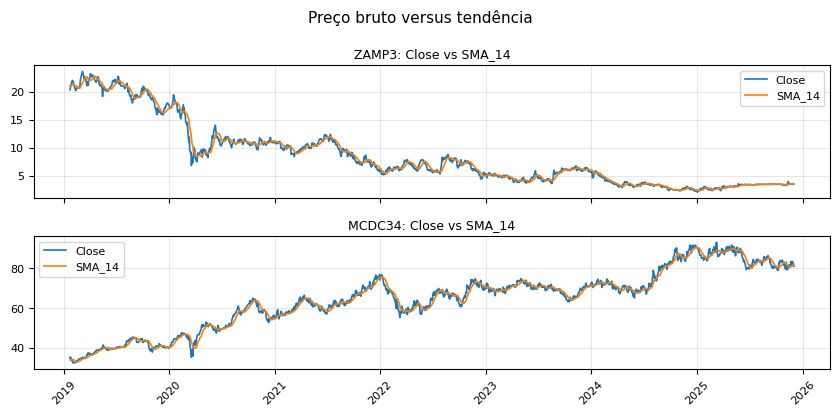

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Limitações </center>

As escolhas de modelagem feitas neste trabalho (uso de LSTM, conjunto específico de indicadores técnicos e janelas temporais) devem ser tratadas como **hipóteses testáveis**, não como solução definitiva para previsão de retornos. Outros modelos (ARIMA, modelos lineares, Transformers, CNNs temporais) ou outros conjuntos de features poderiam, em princípio, produzir resultados diferentes ou melhores, o que torna a própria arquitetura adotada passível de contestação.


&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;


# <center> Conclusão </center>

Concluída a etapa de engenharia e motivação das features, a próxima seção apresenta a implementação do modelo LSTM, incluindo preparação das janelas temporais, divisão treino/validação e configuração da arquitetura.

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;

#<center> **O CÓDIGO** </center>

&nbsp;&nbsp;&nbsp;&nbsp;


### Configuração de dependências e bibliotecas

Este bloco realiza a instalação e a importação das principais dependências utilizadas no projeto:

- **Instalação de pacotes**  
  - `yfinance`, `matplotlib`, `scikit-learn` e `torch` são instalados via `pip` para garantir que todas as bibliotecas necessárias estejam disponíveis no ambiente.

- **Bibliotecas de manipulação de dados e visualização**  
  - `numpy` e `pandas`: usados para manipulação de arrays numéricos e dataframes de séries temporais.  
  - `matplotlib.pyplot`: utilizado para gerar gráficos e visualizações dos dados e resultados.

- **Coleta e pré-processamento de dados**  
  - `yfinance`: responsável por baixar séries históricas de preços e volumes diretamente do Yahoo Finance.  
  - `MinMaxScaler` (scikit-learn): usado para normalizar/escala os dados numéricos antes de alimentar o modelo LSTM.

- **Ferramentas de deep learning (PyTorch)**  
  - `torch` e `torch.nn`: fornecem a infraestrutura para definição da arquitetura LSTM e demais camadas da rede neural.  
  - `Dataset` e `DataLoader`: facilitam a criação de conjuntos de dados sequenciais e o carregamento em mini-batches durante o treinamento do modelo.

In [ ]:
!pip install yfinance matplotlib scikit-learn torch --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

### Função `add_indicators`: criação básica de indicadores técnicos

Esta função recebe um `DataFrame` de preços e adiciona três indicadores clássicos de análise técnica sobre uma coluna de referência (por padrão, `Close`):

- **SMA (Simple Moving Average)**  
  - `SMA_{window}`: média móvel simples do preço de fechamento em uma janela de `window` períodos.  
  - Serve para suavizar oscilações de curto prazo e evidenciar a tendência recente do ativo.

- **EMA (Exponential Moving Average)**  
  - `EMA_{window}`: média móvel exponencial com span igual a `window`, que dá mais peso aos preços mais recentes.  
  - Captura mudanças de tendência de forma mais rápida que a SMA.

- **RSI (Relative Strength Index)**  
  - `RSI_{window}`: indicador de momento calculado a partir das médias de ganhos e perdas nos últimos `window` períodos.  
  - Mede a força relativa dos movimentos de alta e baixa, ajudando a identificar regiões de pressão compradora ou vendedora.

Ao final, a função retorna o `DataFrame` original acrescido dessas colunas, que serão usadas como features de tendência e momento no modelo LSTM.

In [ ]:
# Função com pandas puro para calcular indicadores
def add_indicators(df, col='Close', window=14):
    df[f'SMA_{window}'] = df[col].rolling(window=window).mean()
    df[f'EMA_{window}'] = df[col].ewm(span=window, adjust=False).mean()
    delta = df[col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    df[f'RSI_{window}'] = 100 - (100 / (1 + rs))
    return df

### Definição de parâmetros e janelas

Nesta etapa são definidos os ativos, o período de análise (2019–2025) e os parâmetros usados na engenharia de atributos. As janelas escolhidas seguem práticas consolidadas de análise técnica e serão utilizadas apenas na construção dos indicadores, e não como janela de entrada da LSTM.

---

### Justificativa das janelas dos indicadores

Os parâmetros `WINDOW = 14` e `VOL_WINDOW = 10` são utilizados no cálculo dos indicadores técnicos e **não correspondem à janela de contexto da LSTM**.

- **`WINDOW = 14` (tendência e momento)**  
  - O período de 14 é o padrão clássico para cálculo do RSI e amplamente adotado em plataformas e materiais de análise técnica, justamente por equilibrar sensibilidade e suavização de ruído em relação a horizontes mais curtos ou mais longos. [web:156][web:157][web:160][web:165]  
  - Esse mesmo horizonte também é usado com frequência em médias móveis simples e exponenciais, servindo como referência de tendência de curto prazo. [web:161]  

- **`VOL_WINDOW = 10` (volatilidade e volume)**  
  - Utiliza-se uma janela um pouco menor (10 dias) para volatilidade e métricas de volume, de forma a tornar essas medidas mais responsivas a mudanças rápidas em risco e liquidez de mercado, prática comum em modelos que monitoram volatilidade de curto prazo. [web:163]  

---

### Diferença em relação à LSTM

As janelas acima servem para **criar features locais** (RSI_14, SMA_14, Volatility_10, Volume_MA_10 etc.), isto é, resumos de comportamento em horizontes curtos.  

A LSTM, por sua vez, utilizará posteriormente uma **janela própria de sequência de entrada** (input window) para aprender dependências temporais de maior alcance. Estudos mostram que o desempenho da LSTM depende fortemente do comprimento dessa janela de entrada, que é um hiperparâmetro distinto das janelas usadas em indicadores. [web:162][web:164]  

Em resumo:  
- **Indicadores (14 e 10 períodos)** → capturam padrões de curto prazo e reduzem ruído.  
- **LSTM (janela de entrada)** → aprende relações temporais entre esses padrões ao longo de horizontes mais longos.


# links

[Índice de Força Relativa (RSI): conceito e uso do período 14](https://www.investopedia.com/terms/r/rsi.asp) – descreve o RSI com período padrão de 14 como configuração clássica de mercado.

[Understanding the Relative Strength Index (RSI) | OANDA](https://www.oanda.com/us-en/trade-tap-blog/trading-knowledge/understanding-the-relative-strength-index/) – detalha o RSI e reforça o uso de 14 períodos como configuração default.  

[Simple Moving Average (SMA) – A Backbone of Technical Analysis](https://ninjatrader.com/futures/blogs/simple-moving-average-sma-a-backbone-of-technical-analysis/) – discute o uso de médias móveis em períodos de curto prazo (como 10 e 14) para suavizar ruído e capturar tendência.

[Stock Trend Prediction Using LSTM with MA, EMA, MACD and RSI](https://iuojs.intimal.edu.my/index.php/intijournal/article/download/132/125/372) – exemplo de uso de indicadores técnicos (incluindo RSI_14 e médias móveis) como features para LSTM, separados da janela de sequência usada pela rede.

[Visual prediction method based on time series–driven LSTM model](https://www.nature.com/articles/s41598-025-21911-9) – discute a importância da escolha da janela de entrada (sequence length) na LSTM, distinta dos horizontes usados em transformações locais da série.

In [ ]:
CSV_BK_PATH = "/content/ZAMP3_2018_2025.csv"
tickers = ['MCDC34.SA', 'MEAL3.SA', 'SBUB34.SA']
ticker_cambio = 'BRL=X'

START_DATE = '2019-01-01'
END_DATE = '2025-12-02'
WINDOW = 14
VOL_WINDOW = 10

dfs = []

### Função de engenharia de atributos para ativos com volume

A função `add_features_prefixed()` cria variáveis derivadas para os ativos que possuem informações completas de preço e volume. Inicialmente, as colunas originais são organizadas com um prefixo identificador do ativo, o que facilita a consolidação posterior em um único dataset multivariado.

Em seguida, são calculados indicadores de tendência (`SMA` e `EMA`), momento (`RSI`, retorno de 1 dia e retorno de 5 dias), volatilidade (`desvio padrão móvel dos retornos`), amplitude intradiária (`Range`), retorno entre abertura e fechamento (`OC_Return`) e posição relativa do preço em relação às médias móveis (`Close_vs_SMA` e `Close_vs_EMA`).

Para a dimensão de liquidez, a função também gera métricas baseadas em volume, como variação diária, média móvel e volume relativo. Ao final, valores infinitos são substituídos por `NaN`, evitando problemas numéricos decorrentes de divisões por zero.

In [ ]:
# ==================================================
# Função para ativos com volume
# ==================================================
def add_features_prefixed(df, prefix, window=14, vol_window=10):
    df = df.copy().sort_index()

    open_col = f'{prefix}_Open'
    high_col = f'{prefix}_High'
    low_col = f'{prefix}_Low'
    close_col = f'{prefix}_Close'
    volume_col = f'{prefix}_Volume'

    df[f'{prefix}_SMA_{window}'] = df[close_col].rolling(window=window, min_periods=window).mean()
    df[f'{prefix}_EMA_{window}'] = df[close_col].ewm(span=window, adjust=False).mean()

    delta = df[close_col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    df[f'{prefix}_RSI_{window}'] = 100 - (100 / (1 + rs))

    df[f'{prefix}_Return_1d'] = df[close_col].pct_change(1)
    df[f'{prefix}_Return_5d'] = df[close_col].pct_change(5)

    df[f'{prefix}_Volatility_{vol_window}'] = df[f'{prefix}_Return_1d'].rolling(
        window=vol_window, min_periods=vol_window
    ).std()

    df[f'{prefix}_Range'] = (df[high_col] - df[low_col]) / df[close_col].replace(0, np.nan)
    df[f'{prefix}_OC_Return'] = (df[close_col] - df[open_col]) / df[open_col].replace(0, np.nan)

    df[f'{prefix}_Close_vs_SMA'] = (
        df[close_col] / df[f'{prefix}_SMA_{window}'].replace(0, np.nan) - 1
    )
    df[f'{prefix}_Close_vs_EMA'] = (
        df[close_col] / df[f'{prefix}_EMA_{window}'].replace(0, np.nan) - 1
    )

    vol_prev = df[volume_col].shift(1)
    df[f'{prefix}_Volume_Change'] = (
        (df[volume_col] - vol_prev) / vol_prev.replace(0, np.nan)
    )

    df[f'{prefix}_Volume_MA_{vol_window}'] = df[volume_col].rolling(
        window=vol_window, min_periods=vol_window
    ).mean()

    df[f'{prefix}_Volume_Relative'] = (
        df[volume_col] / df[f'{prefix}_Volume_MA_{vol_window}'].replace(0, np.nan)
    )

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


### Função de engenharia de atributos para o câmbio

A função `add_features_fx()` aplica ao câmbio a mesma lógica de engenharia de atributos utilizada nos ativos, porém sem incluir variáveis associadas a volume. São gerados indicadores de tendência (`SMA` e `EMA`), momento (`RSI`, retorno de 1 dia e retorno de 5 dias), volatilidade, amplitude intradiária e retorno entre abertura e fechamento.

Além disso, são calculadas medidas de posição relativa do preço em relação às médias móveis, permitindo representar o comportamento do câmbio de forma comparável às demais séries do dataset. Ao final, valores infinitos são substituídos por `NaN`, preservando a consistência numérica da base.

In [ ]:
# ==================================================
# Função para câmbio (sem volume)
# ==================================================
def add_features_fx(df, prefix, window=14, vol_window=10):
    df = df.copy().sort_index()

    open_col = f'{prefix}_Open'
    high_col = f'{prefix}_High'
    low_col = f'{prefix}_Low'
    close_col = f'{prefix}_Close'

    df[f'{prefix}_SMA_{window}'] = df[close_col].rolling(window=window, min_periods=window).mean()
    df[f'{prefix}_EMA_{window}'] = df[close_col].ewm(span=window, adjust=False).mean()

    delta = df[close_col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    df[f'{prefix}_RSI_{window}'] = 100 - (100 / (1 + rs))

    df[f'{prefix}_Return_1d'] = df[close_col].pct_change(1)
    df[f'{prefix}_Return_5d'] = df[close_col].pct_change(5)

    df[f'{prefix}_Volatility_{vol_window}'] = df[f'{prefix}_Return_1d'].rolling(
        window=vol_window, min_periods=vol_window
    ).std()

    df[f'{prefix}_Range'] = (df[high_col] - df[low_col]) / df[close_col].replace(0, np.nan)
    df[f'{prefix}_OC_Return'] = (df[close_col] - df[open_col]) / df[open_col].replace(0, np.nan)

    df[f'{prefix}_Close_vs_SMA'] = (
        df[close_col] / df[f'{prefix}_SMA_{window}'].replace(0, np.nan) - 1
    )
    df[f'{prefix}_Close_vs_EMA'] = (
        df[close_col] / df[f'{prefix}_EMA_{window}'].replace(0, np.nan) - 1
    )

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


### Carregamento e padronização das séries

Nesta etapa, a série da ZAMP3 é carregada a partir do arquivo CSV da B3, com conversão da coluna de data, ordenação cronológica, filtro pelo período de interesse e remoção de datas duplicadas. Em seguida, as colunas OHLCV são renomeadas para o padrão `ZAMP3_*`, e a função de engenharia de atributos é aplicada. A última data disponível da ZAMP3 também é armazenada para definir o limite temporal da base consolidada.

Para os demais ativos (`MCDC34`, `MEAL3` e `SBUB34`), os dados são obtidos via `yfinance`, reorganizados, padronizados com prefixos próprios e enriquecidos com a mesma função de atributos utilizada para a ZAMP3.

Por fim, a série de câmbio USD/BRL é carregada via `yfinance`, padronizada para o formato `USDBRL_*` e processada pela função específica para ativos sem volume. Ao término deste bloco, cada série já está estruturada de forma compatível para a consolidação do dataset multivariado.

In [ ]:
# ==================================================
# ZAMP3 via CSV
# ==================================================
df_bk = pd.read_csv(CSV_BK_PATH)
df_bk['Date'] = pd.to_datetime(df_bk['Date'])
df_bk = df_bk.sort_values('Date')
df_bk = df_bk[(df_bk['Date'] >= START_DATE) & (df_bk['Date'] < END_DATE)].copy()

# caso haja duplicidade de data, mantém a última
df_bk = df_bk.drop_duplicates(subset=['Date'], keep='last')
df_bk = df_bk.set_index('Date')

df_bk = df_bk[['Open', 'High', 'Low', 'Close', 'Volume']].rename(columns={
    'Open': 'ZAMP3_Open',
    'High': 'ZAMP3_High',
    'Low': 'ZAMP3_Low',
    'Close': 'ZAMP3_Close',
    'Volume': 'ZAMP3_Volume'
})

df_bk = add_features_prefixed(df_bk, prefix='ZAMP3', window=WINDOW, vol_window=VOL_WINDOW)
dfs.append(df_bk)

# última data disponível da ZAMP3
data_limite = df_bk.index.max()

# ==================================================
# Outros ativos via Yahoo
# ==================================================
for t in tickers:
    df = yf.download(t, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.sort_index()

    prefix = t.replace('.SA', '')

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].rename(columns={
        'Open': f'{prefix}_Open',
        'High': f'{prefix}_High',
        'Low': f'{prefix}_Low',
        'Close': f'{prefix}_Close',
        'Volume': f'{prefix}_Volume'
    })

    df = add_features_prefixed(df, prefix=prefix, window=WINDOW, vol_window=VOL_WINDOW)
    dfs.append(df)


# ==================================================
# Dólar USD/BRL via Yahoo
# ==================================================
df_fx = yf.download(ticker_cambio, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)

if isinstance(df_fx.columns, pd.MultiIndex):
    df_fx.columns = df_fx.columns.get_level_values(0)

df_fx = df_fx.sort_index()

df_fx = df_fx[['Open', 'High', 'Low', 'Close']].rename(columns={
    'Open': 'USDBRL_Open',
    'High': 'USDBRL_High',
    'Low': 'USDBRL_Low',
    'Close': 'USDBRL_Close'
})

df_fx = add_features_fx(df_fx, prefix='USDBRL', window=WINDOW, vol_window=VOL_WINDOW)
dfs.append(df_fx)


### Diagnóstico de `NaN` em variáveis geradas por janelas móveis

Este bloco seleciona as colunas associadas a indicadores calculados com janelas móveis, como `SMA`, `EMA`, `RSI`, `Volatility` e `Volume_MA`, e contabiliza a quantidade de valores ausentes em cada uma delas.

O objetivo é verificar empiricamente o impacto das operações de `rolling` na geração de `NaN`. Como esses indicadores exigem um número mínimo de observações anteriores para serem calculados, é esperado que apresentem valores ausentes no início da série. A ordenação decrescente permite identificar quais variáveis concentram maior quantidade de `NaN`, reforçando que esses valores decorrem da própria lógica de construção das features.

In [ ]:
cols_rolling = [c for c in data_sem_drop.columns if any(x in c for x in ['SMA', 'EMA', 'RSI', 'Volatility', 'Volume_MA'])]
na_rolling = data_sem_drop[cols_rolling].isna().sum().sort_values(ascending=False)


display(na_rolling.head(20))

,0
MEAL3_RSI_14,93
MCDC34_RSI_14,93
SBUB34_RSI_14,93
SBUB34_Close_vs_SMA,92
SBUB34_SMA_14,92
MCDC34_SMA_14,92
MCDC34_Close_vs_SMA,92
MEAL3_SMA_14,92
MEAL3_Close_vs_SMA,92
ZAMP3_RSI_14,92


### Diagnóstico de `NaN` em variáveis de retorno

Neste bloco são selecionadas as colunas relacionadas a retornos e variações percentuais, como `Return_1d`, `Return_5d` e `OC_Return`, para contabilizar a quantidade de valores ausentes em cada uma.

O objetivo é verificar empiricamente o efeito de operações que dependem de observações passadas, como `pct_change`. Como esses cálculos exigem pelo menos um valor anterior — ou mais, no caso de retornos em múltiplos períodos — é esperado que os `NaN` se concentrem nas primeiras linhas da série. A ordenação dos resultados facilita a identificação das variáveis mais afetadas e confirma que esses valores ausentes são estruturais, e não erro de processamento.

In [ ]:
cols_ret = [c for c in data_sem_drop.columns if any(x in c for x in ['Return_1d', 'Return_5d', 'OC_Return'])]
na_ret = data_sem_drop[cols_ret].isna().sum().sort_values(ascending=False)


display(na_ret)

,0
MCDC34_Return_5d,84
SBUB34_Return_5d,84
MEAL3_Return_5d,84
ZAMP3_Return_5d,83
SBUB34_Return_1d,80
MEAL3_Return_1d,80
MCDC34_Return_1d,80
SBUB34_OC_Return,79
MCDC34_OC_Return,79
ZAMP3_Return_1d,79


### Inspeção visual dos `NaN` em variáveis de retorno

Este bloco exibe as primeiras observações das variáveis de retorno, permitindo uma verificação visual da distribuição dos valores ausentes no início da série.

A visualização evidencia que os `NaN` estão concentrados nas primeiras linhas, o que confirma que sua origem está relacionada à dependência de valores passados nas operações de `pct_change` e `diff`. À medida que a série avança, os valores passam a ser preenchidos normalmente, reforçando o caráter estrutural desses `NaN`.

In [ ]:
display(data_sem_drop[cols_ret].head(8))

,ZAMP3_Return_1d,ZAMP3_Return_5d,ZAMP3_OC_Return,MCDC34_Return_1d,MCDC34_Return_5d,MCDC34_OC_Return,MEAL3_Return_1d,MEAL3_Return_5d,MEAL3_OC_Return,SBUB34_Return_1d,SBUB34_Return_5d,SBUB34_OC_Return,USDBRL_Return_1d,USDBRL_Return_5d,USDBRL_OC_Return
Date,,,,,,,,,,,,,,,
2019-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
2019-01-02,NaN,NaN,0.002914,NaN,NaN,-0.010484,NaN,NaN,-0.016949,NaN,NaN,0.001920,-0.000026,NaN,0.000000
2019-01-03,0.027119,NaN,0.000472,-0.022202,NaN,0.000000,-0.008621,NaN,0.001451,-0.052973,NaN,0.000000,-0.024124,NaN,-0.000079
2019-01-04,-0.002829,NaN,-0.009831,0.015706,NaN,0.000000,0.007246,NaN,0.014599,0.026138,NaN,0.000000,-0.008240,NaN,0.000027
2019-01-07,-0.007092,NaN,-0.000476,0.013545,NaN,0.000000,-0.005755,NaN,-0.005755,0.000504,NaN,-0.000880,-0.025006,NaN,-0.014137
2019-01-08,0.002381,NaN,0.002381,-0.013009,NaN,-0.005422,0.013025,NaN,0.013025,-0.008472,NaN,0.002502,0.019912,-0.037603,-0.000027
2019-01-09,-0.002375,0.016949,-0.009434,-0.001318,-0.007798,0.003552,0.000000,0.005747,0.001431,-0.004653,-0.040453,0.002685,-0.005811,-0.043171,0.000108
2019-01-10,0.000000,-0.009901,-0.003795,0.006779,0.021611,-0.007687,-0.014286,0.000000,-0.005764,0.015002,0.028420,0.000000,-0.008727,-0.028075,0.000136


### Diagnóstico de `NaN` por linha ao longo da série temporal

Neste bloco é calculada a quantidade de valores ausentes por data, somando os `NaN` existentes em todas as colunas do dataset para cada linha da série temporal.

O objetivo é identificar se os valores ausentes aparecem apenas no início da base — como esperado para indicadores com janelas móveis, ou se também ocorrem em datas posteriores. Ao inspecionar observações fora do trecho inicial da série, torna-se possível detectar evidências de desalinhamento entre ativos e fontes de dados, mostrando que parte dos `NaN` não decorre apenas do período de aquecimento dos indicadores, mas também da ausência pontual de registros em determinadas datas.

In [ ]:
na_por_linha = data_sem_drop.isna().sum(axis=1)

display(na_por_linha[na_por_linha > 0].iloc[30:60])

,0
Date,
2019-03-08,1
2019-03-11,1
2019-03-19,1
2019-03-20,1
2019-03-26,1
2019-04-04,2
2019-04-09,1
2019-04-11,1
2019-04-12,1


### Consolidação e limpeza final do dataset

Após o processamento individual de cada série, todos os dataframes são **alinhados pelo índice de data e concatenados em colunas**, resultando em uma base multivariada única que reúne, para cada dia, os preços, volumes e indicadores técnicos de todos os ativos e do câmbio. Em seguida, o período é truncado até a última data disponível de ZAMP3, garantindo que não existam observações em que o ativo principal esteja ausente.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

### Por que surgem valores NaN?

Os `NaN` gerados ao longo da construção do dataset não são um erro do código, mas consequência natural de três tipos de operação:

- **Janelas móveis (rolling)**  
  Indicadores como médias móveis, volatilidade e RSI utilizam operações de janela (`rolling`). Enquanto a janela não está completa (por exemplo, nos primeiros 10 ou 14 dias), o pandas retorna `NaN` para essas posições, conforme documentado na API de `rolling`.

- **Retornos e variações percentuais**  
  Cálculos de retorno (`pct_change`) e diferenças (`diff`) produzem `NaN` na primeira observação, pois não existe valor anterior para comparação, e podem gerar valores inválidos quando o denominador é zero, que depois são convertidos para `NaN`.  

- **Concatenação de séries com calendários diferentes**  
  Ao concatenar dataframes com índices de datas que não coincidem perfeitamente, o pandas faz a união desses índices; nas datas em que um ativo não tem registro (por ausência de negociação, feriado específico etc.), as colunas correspondentes permanecem `NaN`.

---
&nbsp;&nbsp;&nbsp;&nbsp;

### Remoção dos NaNs e impacto no dataset

Depois de gerar todas as features e alinhar as séries, é aplicado `data = data_sem_drop.dropna()`, removendo todas as linhas com qualquer valor ausente. Essa decisão é importante por dois motivos:

- **Consistência numérica para o modelo**  
  Normalizadores como `MinMaxScaler` e redes LSTM assumem entradas numéricas finitas; a presença de `NaN` ou `inf` quebra o ajuste do scaler e o treinamento da rede. Por isso, é prática comum eliminar ou tratar explicitamente observações incompletas em séries financeiras antes de treinar modelos de deep learning.

- **Baixo custo informacional**  
  A maioria dos `NaN` aparece:
  - no início das séries (período de “aquecimento” das janelas de 10/14 dias),  
  - nas primeiras linhas de retornos,  
  - em poucos dias isolados sem negociação para algum ativo.  

  Assim, a remoção tende a afetar principalmente esses pontos marginais, preservando quase integralmente o horizonte de interesse (2019–2025). Em geral, o percentual de linhas removidas é pequeno em relação ao total de observações, e o código imprime essa estatística para tornar o impacto transparente.

---
&nbsp;&nbsp;&nbsp;&nbsp;

### Diagnóstico da limpeza

Por fim, o bloco exibe:

- dimensões da base antes e depois do `dropna`,  
- número e percentual de linhas removidas,  
- período final efetivo (data inicial e final) e  
- total de colunas (features) do dataset resultante.

Essas informações permitem avaliar que o processo de limpeza:

- remove principalmente registros estruturalmente incompletos,  
- não compromete a representatividade do intervalo 2019–2025 e  
- gera um conjunto de dados numérica e temporalmente consistente para o treinamento da LSTM.

&nbsp;&nbsp;&nbsp;&nbsp;

Links:
[pandas.DataFrame.rolling — documentação oficial](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html) – descreve que operações em janelas retornam `NaN` enquanto não há observações suficientes para completar a janela. [web:167]  

[Windowing operations — pandas user guide](https://pandas.pydata.org/docs/user_guide/window.html) – detalha o comportamento de funções de janela (rolling), incluindo a presença de `NaN` no início da série.

In [ ]:
# ==================================================
# Consolidação final
# ==================================================
data_sem_drop = pd.concat(dfs, axis=1)

# corta tudo no fim da ZAMP3
data_sem_drop = data_sem_drop.loc[:data_limite]

data = data_sem_drop.dropna()

print("Data limite usada:", data_limite)
print("Shape sem dropna:", data_sem_drop.shape)
print("Shape com dropna:", data.shape)
print("Linhas perdidas:", len(data_sem_drop) - len(data))
print("Percentual perdido:", round((len(data_sem_drop) - len(data)) / len(data_sem_drop) * 100, 2), "%")

print("\nPeríodo final:")
print("Início:", data.index.min())
print("Fim:", data.index.max())

print("\nTotal de colunas:", len(data.columns))

data.head(2)

Data limite usada: 2025-12-01 00:00:00
Shape sem dropna: (1802, 86)
Shape com dropna: (1557, 86)
Linhas perdidas: 245
Percentual perdido: 13.6 %

Período final:
Início: 2019-01-23 00:00:00
Fim: 2025-12-01 00:00:00

Total de colunas: 86


,ZAMP3_Open,ZAMP3_High,ZAMP3_Low,ZAMP3_Close,ZAMP3_Volume,ZAMP3_SMA_14,ZAMP3_EMA_14,ZAMP3_RSI_14,ZAMP3_Return_1d,ZAMP3_Return_5d,...,USDBRL_SMA_14,USDBRL_EMA_14,USDBRL_RSI_14,USDBRL_Return_1d,USDBRL_Return_5d,USDBRL_Volatility_10,USDBRL_Range,USDBRL_OC_Return,USDBRL_Close_vs_SMA,USDBRL_Close_vs_EMA
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-23,20.24,20.86,20.11,20.35,1225300.0,21.079286,20.909949,38.624339,0.000000,-0.055684,...,3.722929,3.755416,52.673194,0.016154,0.025724,0.008591,0.009523,-0.000446,0.023925,0.015067
2019-01-24,20.18,20.78,20.18,20.70,797300.0,21.047143,20.881956,44.471744,0.017199,-0.039889,...,3.723443,3.756334,50.721154,-0.013038,0.007498,0.009306,0.014831,-0.000080,0.010436,0.001588


### Transformação logarítmica dos preços de fechamento

Após a consolidação e limpeza da base, são criadas variáveis correspondentes ao logaritmo do preço de fechamento de cada ativo. Essa transformação é útil porque reduz o efeito das diferenças de escala entre os papéis, tornando as séries mais comparáveis entre si.

Além disso, o uso de `log(Close)` preserva a informação de nível do preço, mas em uma forma mais adequada para modelagem do que o valor bruto, especialmente em um contexto multivariado com ativos de magnitudes distintas.

In [ ]:
data = data_sem_drop.dropna().copy()

for ativo in ['ZAMP3', 'MCDC34', 'MEAL3', 'SBUB34']:
    data[f'{ativo}_LogClose'] = np.log(data[f'{ativo}_Close'])

### Normalização dos dados com `MinMaxScaler`


Nesta etapa, todas as variáveis do dataset consolidado são normalizadas com `MinMaxScaler`, que transforma cada coluna para a faixa entre 0 e 1.

A normalização é importante porque as features possuem escalas muito diferentes — por exemplo, preços, volumes, retornos e indicadores técnicos. Sem esse ajuste, variáveis com magnitude maior poderiam dominar o processo de treinamento da rede. Ao padronizar as escalas, o modelo passa a aprender com maior estabilidade numérica e melhor equilíbrio entre as diferentes entradas.


In [ ]:
# Normalizando os dados multivariados
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

In [ ]:
#Célula para ver os dados normalizados dentro da escala de 0 a 1
scaled_df = pd.DataFrame(scaled, columns=data.columns, index=data.index)
scaled_df.head(2)

,ZAMP3_Open,ZAMP3_High,ZAMP3_Low,ZAMP3_Close,ZAMP3_Volume,ZAMP3_SMA_14,ZAMP3_EMA_14,ZAMP3_RSI_14,ZAMP3_Return_1d,ZAMP3_Return_5d,...,USDBRL_Return_5d,USDBRL_Volatility_10,USDBRL_Range,USDBRL_OC_Return,USDBRL_Close_vs_SMA,USDBRL_Close_vs_EMA,ZAMP3_LogClose,MCDC34_LogClose,MEAL3_LogClose,SBUB34_LogClose
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-23,0.837650,0.852444,0.851205,0.847261,0.026427,0.918043,0.91408,0.378742,0.550425,0.330441,...,0.697774,0.176091,0.108989,0.634556,0.666755,0.636728,0.938100,0.074182,0.854302,0.008617
2019-01-24,0.834875,0.848789,0.854511,0.863510,0.017073,0.916465,0.91270,0.444673,0.587487,0.345367,...,0.597842,0.198425,0.198540,0.638558,0.587098,0.546506,0.945144,0.086379,0.861194,0.002281


### Definição das variáveis alvo da carteira

Neste bloco são definidas as colunas que representarão as variáveis alvo do modelo. Em vez de prever preços de fechamento, optou-se por utilizar os retornos diários (`Return_1d`) dos ativos que compõem a carteira: ZAMP3, MCDC34, MEAL3 e SBUB34.

Em seguida, essas colunas são convertidas em índices posicionais dentro do dataset, gerando `target_idx`. Essa etapa é necessária porque, na construção das sequências temporais, o array normalizado é acessado por posição e não por nome de coluna. Dessa forma, o modelo passa a prever simultaneamente os retornos futuros dos componentes da carteira.

In [ ]:
target_cols = [
    'ZAMP3_Return_1d',
    'MCDC34_Return_1d',
    'MEAL3_Return_1d',
    'SBUB34_Return_1d'
]

target_idx = [data.columns.get_loc(col) for col in target_cols]
target_idx

[8, 26, 44, 62]

### Criação das sequências temporais e divisão entre treino e teste

### Criação das sequências temporais e divisão entre treino e teste

Neste bloco, o dataset normalizado é reorganizado em sequências temporais no formato tridimensional exigido pela LSTM: `[n_amostras, n_passos, n_features]`. Cada amostra de entrada contém uma janela histórica multivariada com tamanho fixo de 7 períodos (`seq_len = 7`).

A escolha de uma janela de 7 períodos está alinhada ao estudo de objeto, que destaca a recorrência semanal no consumo do setor de fast-food. Como o objetivo é prever retornos de curto prazo, essa configuração busca preservar um ciclo completo de comportamento semanal, tornando a janela mais coerente com a dinâmica que se deseja capturar.

Como a previsão é feita de forma conjunta para os ativos da carteira, a saída `y` deixa de ser um valor escalar e passa a ser um vetor com quatro alvos, correspondentes aos retornos futuros de ZAMP3, MCDC34, MEAL3 e SBUB34.

Após a construção das sequências, os dados são separados em treino e teste por ordem temporal, utilizando 80% das observações para treinamento e 20% para avaliação. Essa divisão preserva a estrutura cronológica da série e evita vazamento de informação entre passado e futuro. As dimensões impressas ao final permitem verificar se o formato dos dados está compatível com a entrada esperada pela rede.

In [ ]:
seq_len = 7

target_cols = [
    'ZAMP3_Return_5d',
    'MCDC34_Return_5d',
    'MEAL3_Return_5d',
    'SBUB34_Return_5d'
]

target_idx = [data.columns.get_loc(col) for col in target_cols]

X, y = create_multivariate_sequences(scaled, seq_len, target_idx)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Targets:", target_cols)
print("Shape X_train:", X_train.shape)
print("Shape y_train:", y_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_test:", y_test.shape)

Targets: ['ZAMP3_Return_5d', 'MCDC34_Return_5d', 'MEAL3_Return_5d', 'SBUB34_Return_5d']
Shape X_train: (1240, 7, 90)
Shape y_train: (1240, 4)
Shape X_test: (310, 7, 90)
Shape y_test: (310, 4)


### `Dataset` para séries temporais multivariadas

A classe `TimeSeriesDataset` encapsula as sequências de entrada (`X`) e os alvos (`y`) no formato esperado pelo PyTorch. Nesse processo, ambos são convertidos para tensores `float32`, permitindo que a base seja consumida diretamente pelo modelo durante o treinamento.

Essa etapa separa a preparação dos dados da rotina de treino propriamente dita, tornando o pipeline mais organizado e compatível com o ecossistema do PyTorch. Além disso, a implementação dos métodos `__len__` e `__getitem__` permite acessar cada amostra sequencialmente, preservando a estrutura temporal já construída anteriormente.

A conversão para Dataset e DataLoader separa a lógica de preparação da base da rotina de treinamento em PyTorch. Isso permite trabalhar com mini-lotes de forma consistente, sem perder a estrutura sequencial necessária para a modelagem de séries temporais.

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### Criação dos conjuntos de treino e teste em PyTorch

Neste bloco, as sequências já separadas em treino e teste são encapsuladas na classe `TimeSeriesDataset`, permitindo que sejam manipuladas no formato esperado pelo PyTorch. Em seguida, são criados os objetos `DataLoader`, responsáveis por organizar os dados em mini-lotes (`batch_size=32`) ao longo do treinamento e da avaliação.

O `train_loader` utiliza embaralhamento (`shuffle=True`) para variar a composição dos lotes durante o treino, enquanto o `test_loader` mantém a ordem original das amostras, preservando a consistência da etapa de avaliação. Essa estrutura facilita o fluxo de alimentação da rede e torna o processo de treinamento mais eficiente.

In [ ]:
train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

### Inspeção visual dos alvos de treino

Como o modelo passa a prever simultaneamente os retornos dos quatro ativos da carteira, a variável `y_train` deixa de ser unidimensional e passa a conter múltiplas saídas. Por esse motivo, a inspeção visual é realizada separadamente para cada alvo, em um arranjo em grade.

Essa visualização permite verificar se os retornos normalizados apresentam variação suficiente ao longo das amostras, além de facilitar a identificação de diferenças de escala relativa e comportamento entre os ativos previstos.

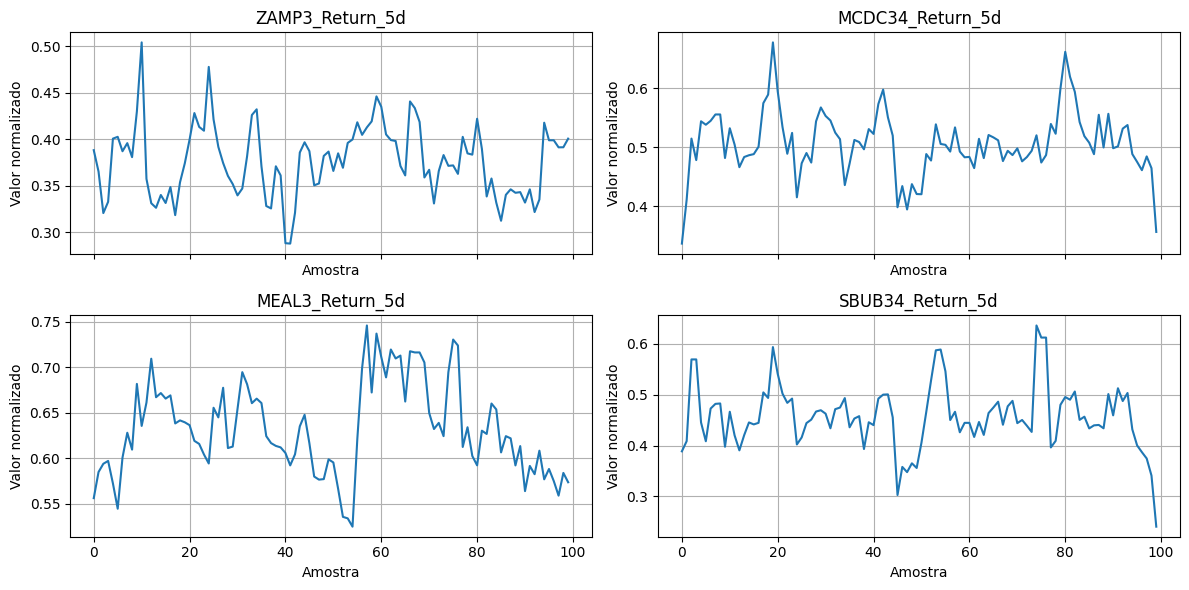

In [ ]:
# 🔍 Verificar a variação dos alvos no conjunto de treino
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

nomes_targets = ['ZAMP3_Return_5d', 'MCDC34_Return_5d', 'MEAL3_Return_5d', 'SBUB34_Return_5d']

for i, ax in enumerate(axes.flatten()):
    ax.plot(y_train[:100, i])
    ax.set_title(nomes_targets[i])
    ax.set_xlabel('Amostra')
    ax.set_ylabel('Valor normalizado')
    ax.grid(True)

plt.tight_layout()
plt.show()

&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;



&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;



### Definição da arquitetura LSTM-GRU

A arquitetura combina uma camada LSTM, voltada à retenção de dependências de maior alcance, com uma camada GRU, responsável por refinar a representação temporal antes da projeção final. Nesta etapa, a preocupação central não é o ajuste fino, mas verificar se a estrutura recorrente consegue extrair sinal preditivo de uma entrada centrada no histórico do preço.


Ao final da arquitetura, utiliza-se uma camada totalmente conectada (`Linear`) aplicada ao último passo temporal da GRU. Como o objetivo do estudo é prever simultaneamente os retornos dos quatro ativos da carteira, a saída do modelo deixa de ser escalar e passa a ter dimensão 4, com uma predição para cada componente da carteira.

Essa configuração permite explorar relações temporais e interdependências entre os ativos em uma única arquitetura recorrente.

In [ ]:
class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size, hidden_lstm=64, hidden_gru=32, output_size=4):
        """
        Modelo híbrido LSTM + GRU para previsão multivariada.

        Parâmetros
        ----------
        input_size : int
            Número de features por passo temporal.
        hidden_lstm : int
            Número de unidades ocultas da camada LSTM.
        hidden_gru : int
            Número de unidades ocultas da camada GRU.
        output_size : int
            Número de saídas do modelo.
            No seu caso, 4 retornos:
            ZAMP3, MCDC34, MEAL3 e SBUB34.
        """
        super().__init__()

        # ==================================================
        # Camada LSTM
        # ==================================================
        # Recebe a sequência multivariada de entrada
        # Shape de entrada: (batch, seq_len, input_size)
        # Shape de saída:   (batch, seq_len, hidden_lstm)
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_lstm,
            batch_first=True
        )

        # ==================================================
        # Camada GRU
        # ==================================================
        # Recebe a saída temporal da LSTM
        # Shape de entrada: (batch, seq_len, hidden_lstm)
        # Shape de saída:   (batch, seq_len, hidden_gru)
        self.gru = nn.GRU(
            input_size=hidden_lstm,
            hidden_size=hidden_gru,
            batch_first=True
        )

        # ==================================================
        # Camada totalmente conectada
        # ==================================================
        # Usa o último estado temporal da GRU para prever
        # simultaneamente os 4 retornos da carteira
        # Shape de entrada: (batch, hidden_gru)
        # Shape de saída:   (batch, output_size)
        self.fc = nn.Linear(hidden_gru, output_size)

    def forward(self, x):
        """
        Passagem direta do modelo.

        Parâmetro
        ---------
        x : torch.Tensor
            Tensor de entrada com shape:
            (batch, seq_len, input_size)

        Retorno
        -------
        torch.Tensor
            Tensor de saída com shape:
            (batch, output_size)
        """

        # ------------------------------
        # 1. Passa pela LSTM
        # ------------------------------
        out_lstm1, _ = self.lstm1(x)

        # ------------------------------
        # 2. Passa pela GRU
        # ------------------------------
        out_gru, _ = self.gru(out_lstm1)

        # ------------------------------
        # 3. Seleciona apenas o último passo temporal
        # ------------------------------
        # out_gru[:, -1, :] -> (batch, hidden_gru)
        last_hidden = out_gru[:, -1, :]

        # ------------------------------
        # 4. Gera as previsões finais
        # ------------------------------
        # saída final -> (batch, output_size)
        final_output = self.fc(last_hidden)

        return final_output

### Inicialização do modelo, função de perda e otimizador

Neste bloco, o número de variáveis de entrada é identificado automaticamente a partir da dimensão das sequências de treino, enquanto o número de saídas é obtido com base na estrutura de `y_train`, garantindo compatibilidade entre a arquitetura e o problema de previsão multivariada.

Em seguida, o modelo é instanciado e enviado para o dispositivo de processamento disponível. Para o treinamento, utiliza-se a função de perda `MSELoss`, apropriada para regressão com múltiplas saídas, e o otimizador `Adam`, escolhido por sua estabilidade e eficiência no ajuste de redes neurais recorrentes.

In [ ]:
# ==================================================
# Inicialização do modelo
# ==================================================

# Número de features por passo temporal
input_size = X_train.shape[2]

# Número de saídas do modelo
# Aqui deve ser 4, uma para cada ativo da carteira
output_size = y_train.shape[1]

# Usa GPU se estiver disponível; caso contrário, usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instancia o modelo já compatível com previsão multivariada
model = LSTM_GRU_Model(
    input_size=input_size,
    hidden_lstm=64,
    hidden_gru=32,
    output_size=output_size
).to(device)

# Função de perda para regressão multivariada
criterion = nn.MSELoss()

# Otimizador Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print("Input size:", input_size)
print("Output size:", output_size)
print("Device:", device)

LSTM_GRU_Model(
  (lstm1): LSTM(90, 64, batch_first=True)
  (gru): GRU(64, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=4, bias=True)
)
Input size: 90
Output size: 4
Device: cpu


## Treinamento do modelo

O treinamento é acompanhado por perdas de treino e validação para avaliar convergência e generalização. Somente depois de estabilizar esse aprendizado estrutural faz sentido avançar para a etapa de otimização, na qual hiperparâmetros como `dropout`, `learning rate` e função de perda passam a ser ajustados de forma mais fina.


Nesta etapa, o modelo é treinado ao longo de várias épocas, com monitoramento simultâneo do desempenho no conjunto de treino e no conjunto de validação. O objetivo não é apenas reduzir o erro sobre os dados usados no ajuste, mas também observar como o modelo se comporta em dados que não estão sendo diretamente utilizados para atualização dos pesos.

Ao final de cada época, são calculadas duas métricas de perda: a *train loss*, que representa o erro médio no conjunto de treino, e a *validation loss*, que representa o erro médio no conjunto de validação. Esse acompanhamento é importante porque permite avaliar se o modelo está realmente aprendendo padrões generalizáveis ou apenas se ajustando excessivamente aos dados de treino.

Além disso, sempre que a perda de validação atinge um novo melhor valor, os pesos atuais do modelo são armazenados. Dessa forma, ao término do treinamento, o modelo restaurado não é necessariamente o da última época, mas sim aquele que apresentou o melhor desempenho observado na validação.

Essa estratégia é especialmente útil em problemas de séries temporais financeiras, nos quais oscilações no treinamento podem fazer com que épocas posteriores não representem, necessariamente, a melhor capacidade de generalização do modelo.


Epoch  1: Train Loss = 0.035983 | Val Loss = 0.005886
Epoch  2: Train Loss = 0.007940 | Val Loss = 0.005737
Epoch  3: Train Loss = 0.007453 | Val Loss = 0.005319
Epoch  4: Train Loss = 0.007253 | Val Loss = 0.005325
Epoch  5: Train Loss = 0.007092 | Val Loss = 0.005139
Epoch  6: Train Loss = 0.006746 | Val Loss = 0.005084
Epoch  7: Train Loss = 0.006442 | Val Loss = 0.004712
Epoch  8: Train Loss = 0.006156 | Val Loss = 0.004509
Epoch  9: Train Loss = 0.005773 | Val Loss = 0.004623
Epoch 10: Train Loss = 0.005534 | Val Loss = 0.004166
Epoch 11: Train Loss = 0.005199 | Val Loss = 0.004229
Epoch 12: Train Loss = 0.004486 | Val Loss = 0.003736
Epoch 13: Train Loss = 0.004052 | Val Loss = 0.003264
Epoch 14: Train Loss = 0.003983 | Val Loss = 0.003452
Epoch 15: Train Loss = 0.003647 | Val Loss = 0.003185
Epoch 16: Train Loss = 0.003384 | Val Loss = 0.003316
Epoch 17: Train Loss = 0.003310 | Val Loss = 0.003412
Epoch 18: Train Loss = 0.003246 | Val Loss = 0.003838
Epoch 19: Train Loss = 0.003

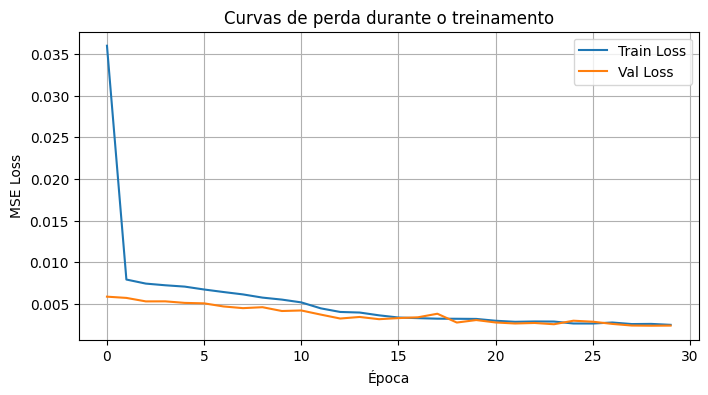

In [ ]:
# ==================================================
# Treinamento com validação por época e salvamento do melhor modelo
# ==================================================

from copy import deepcopy

# Armazena a menor loss de validação observada
best_val_loss = float('inf')

# Guarda os pesos do melhor modelo
best_model_state = None

# Histórico de perdas por época
train_losses = []
val_losses = []

# Número de épocas de treinamento
num_epochs = 30

for epoch in range(1, num_epochs + 1):

    # ------------------------------
    # Etapa de treino
    # ------------------------------
    model.train()
    batch_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Zera os gradientes acumulados
        optimizer.zero_grad()

        # Predição do modelo
        # Shape esperado: (batch_size, 4)
        preds = model(xb)

        # Calcula a perda entre predições e valores reais
        loss = criterion(preds, yb)

        # Backpropagation
        loss.backward()

        # Atualiza os pesos
        optimizer.step()

        # Armazena a loss do batch
        batch_losses.append(loss.item())

    # Loss média de treino na época
    train_loss = np.mean(batch_losses)

    # ------------------------------
    # Etapa de validação
    # ------------------------------
    model.eval()
    val_batch_losses = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)

            # Predição sem atualização de pesos
            preds = model(xb)

            # Loss de validação
            val_loss = criterion(preds, yb)
            val_batch_losses.append(val_loss.item())

    # Loss média de validação na época
    val_loss = np.mean(val_batch_losses)

    # Guarda histórico
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:2d}: Train Loss = {train_loss:.6f} | Val Loss = {val_loss:.6f}")

    # ------------------------------
    # Salva o melhor modelo
    # ------------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

# ==================================================
# Restaura o melhor modelo encontrado
# ==================================================
model.load_state_dict(best_model_state)

# ==================================================
# Plot das curvas de perda
# ==================================================
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Curvas de perda durante o treinamento')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

## Avaliação das previsões no conjunto de teste

Após o treinamento, a próxima etapa consiste em avaliar como o modelo se comporta sobre o conjunto de teste, isto é, em observações que não foram utilizadas diretamente no ajuste dos pesos. Como o modelo foi treinado com múltiplos alvos simultaneamente, a avaliação precisa considerar as quatro saídas previstas em cada amostra.

Nesse processo, as previsões geradas pelo modelo ainda se encontram na escala normalizada utilizada durante o pré-processamento. Por esse motivo, antes de qualquer interpretação prática, é necessário reconverter os valores previstos e os valores reais para a escala original.

Como o `scaler` foi ajustado considerando todas as features do conjunto, a inversão da normalização exige a reconstrução de estruturas completas com o mesmo número de colunas da base transformada. Em seguida, apenas as colunas correspondentes aos alvos são preenchidas, permitindo aplicar corretamente o `inverse_transform` e recuperar os valores previstos e observados em sua escala real.

Por fim, os resultados são organizados em *DataFrames*, o que facilita a inspeção inicial das previsões e sua comparação com os valores reais para cada ativo.

In [ ]:
# ==================================================
# Avaliação do modelo no conjunto de teste
# Correção para scaler multivariado e múltiplos alvos
# ==================================================

model.eval()

preds = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)                  # shape: (batch, 4)
        preds.append(out.cpu().numpy())

# Concatena todos os batches previstos
preds = np.vstack(preds)                 # shape: (n_test, 4)

# y_test já está no formato numpy com shape (n_test, 4)
actual = y_test.copy()

# Reconstrói arrays completos para usar inverse_transform
preds_full = np.zeros((len(preds), scaler.n_features_in_))
actual_full = np.zeros((len(actual), scaler.n_features_in_))

# Preenche apenas as colunas-alvo nas posições corretas
preds_full[:, target_idx] = preds
actual_full[:, target_idx] = actual

# Inverte a normalização
preds_inverse_full = scaler.inverse_transform(preds_full)
actual_inverse_full = scaler.inverse_transform(actual_full)

# Recupera apenas os targets em escala original
preds_inverse = preds_inverse_full[:, target_idx]
actual_inverse = actual_inverse_full[:, target_idx]

# Organiza em DataFrames para facilitar análise
preds_df = pd.DataFrame(preds_inverse, columns=target_cols)
actual_df = pd.DataFrame(actual_inverse, columns=target_cols)

print("Shape previsões:", preds_df.shape)
print("Shape valores reais:", actual_df.shape)

display(preds_df.head())
display(actual_df.head())

Shape previsões: (310, 4)
Shape valores reais: (310, 4)


,ZAMP3_Return_5d,MCDC34_Return_5d,MEAL3_Return_5d,SBUB34_Return_5d
0,0.041282,0.047123,0.004373,-0.006280
1,0.031964,0.033463,0.045630,0.000421
2,-0.005351,0.018524,0.034767,0.008825
3,-0.083243,0.025385,0.008547,0.035416
4,-0.073417,0.020786,-0.009730,0.020782


,ZAMP3_Return_5d,MCDC34_Return_5d,MEAL3_Return_5d,SBUB34_Return_5d
0,0.005797,0.037115,0.094340,-0.010000
1,-0.040115,0.011026,0.054878,0.038792
2,-0.100287,0.017400,0.042424,0.056751
3,-0.078035,0.009091,-0.005988,0.024154
4,-0.104651,-0.000617,-0.006173,0.028015


## Comparação visual entre retornos reais e previstos



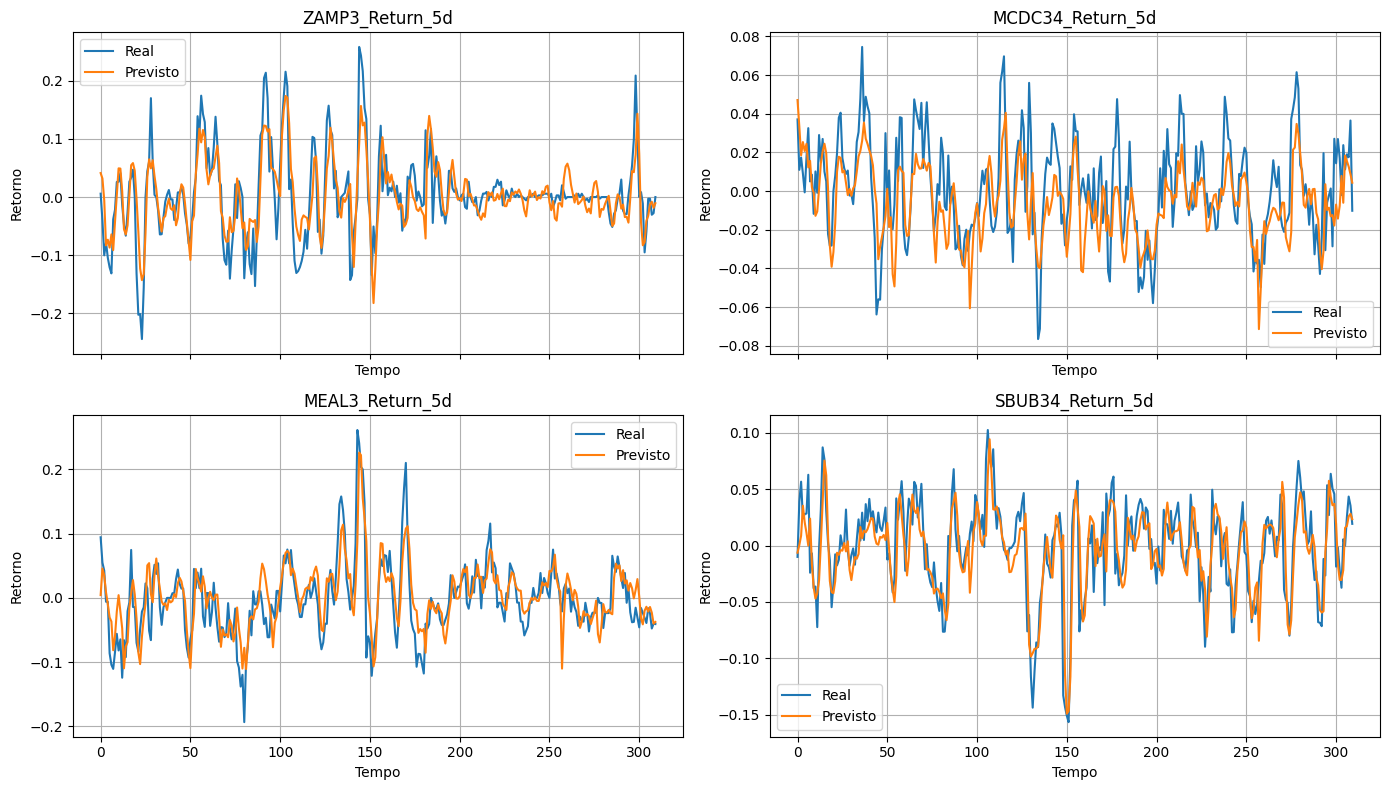

In [ ]:
# ==================================================
# Comparação visual entre retornos reais e previstos
# ==================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for i, ax in enumerate(axes.flatten()):
    col = target_cols[i]
    ax.plot(actual_df[col].values, label='Real')
    ax.plot(preds_df[col].values, label='Previsto')
    ax.set_title(col)
    ax.set_xlabel('Tempo')
    ax.set_ylabel('Retorno')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Métricas de avaliação do modelo por ativo

Após reconstruir os valores previstos e reais em escala original e observar seu comportamento graficamente, a análise passa a incorporar métricas numéricas de desempenho. Essa etapa é importante porque fornece uma visão objetiva da qualidade preditiva do modelo para cada ativo, permitindo comparar resultados de forma mais precisa.

Como o modelo foi treinado com múltiplos alvos, as métricas são calculadas separadamente para cada uma das quatro séries previstas. Isso é relevante porque, mesmo utilizando a mesma arquitetura, cada ativo pode apresentar nível distinto de previsibilidade, volatilidade e sensibilidade aos padrões aprendidos.

Nesta avaliação, são utilizadas quatro medidas principais.

O **MAE** (*Mean Absolute Error*) indica o erro médio absoluto entre valores reais e previstos, oferecendo uma leitura direta da magnitude média dos desvios.

O **RMSE** (*Root Mean Squared Error*) também mede erro, mas penaliza com maior intensidade discrepâncias mais elevadas, sendo útil para identificar previsões com falhas mais acentuadas.

O **R²** avalia o quanto o modelo consegue explicar a variabilidade da série real, embora sua interpretação em séries financeiras de retornos deva ser feita com cautela.

Por fim, a **acurácia direcional** mede a proporção de vezes em que o modelo acerta o sinal do movimento previsto, ou seja, se a variação estimada foi de alta ou de baixa, o que é especialmente relevante em aplicações financeiras orientadas à tendência.

Dessa forma, a combinação dessas métricas permite avaliar não apenas a proximidade numérica entre previsão e realidade, mas também a utilidade prática do modelo para capturar direção e comportamento geral das séries.

In [ ]:
# ==================================================
# Métricas de avaliação por ativo
# ==================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

nomes_amigaveis = {
    'ZAMP3_Return_5d': 'ZAMP3',
    'MCDC34_Return_5d': 'MCDC34',
    'MEAL3_Return_5d': 'MEAL3',
    'SBUB34_Return_5d': 'SBUB34'
}

resultados = []

for col in target_cols:
    y_true = actual_df[col].values
    y_pred = preds_df[col].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    directional_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100

    resultados.append({
        'Ativo': nomes_amigaveis[col],
        'MAE': round(mae, 6),
        'RMSE': round(rmse, 6),
        'R²': round(r2, 4),
        'Acurácia Direcional (%)': round(directional_acc, 2)
    })

metricas_df = pd.DataFrame(resultados)

# ==================================================
# Exibição comentada das métricas
# ==================================================

print("Resumo do desempenho do modelo no conjunto de teste:\n")

for _, row in metricas_df.iterrows():
    print(f"Ativo: {row['Ativo']}")
    print(f"  - MAE: {row['MAE']}")
    print(f"  - RMSE: {row['RMSE']}")
    print(f"  - R²: {row['R²']}")
    print(f"  - Acurácia direcional: {row['Acurácia Direcional (%)']}%")
    print()

Resumo do desempenho do modelo no conjunto de teste:

Ativo: ZAMP3
  - MAE: 0.032828
  - RMSE: 0.046157
  - R²: 0.5947
  - Acurácia direcional: 67.42%

Ativo: MCDC34
  - MAE: 0.016481
  - RMSE: 0.02094
  - R²: 0.3476
  - Acurácia direcional: 72.26%

Ativo: MEAL3
  - MAE: 0.029099
  - RMSE: 0.03857
  - R²: 0.5688
  - Acurácia direcional: 72.58%

Ativo: SBUB34
  - MAE: 0.019766
  - RMSE: 0.02628
  - R²: 0.6026
  - Acurácia direcional: 78.71%



## Continuidade entre histórico observado e previsão futura

Após avaliar o desempenho do modelo no conjunto de teste, esta etapa busca representar de forma mais intuitiva como as previsões futuras se conectariam ao comportamento recente das séries. Em vez de mostrar apenas os valores previstos isoladamente, o gráfico apresenta uma continuidade entre o histórico real mais recente e a trajetória projetada pelo modelo para os próximos períodos.

A lógica adotada é recursiva: a partir da última sequência disponível, o modelo gera a previsão do passo seguinte e, em seguida, essa própria previsão é incorporada à entrada para produzir o próximo passo. Esse procedimento é repetido até completar o horizonte desejado de previsão.

Como o modelo foi treinado para prever simultaneamente os retornos de quatro ativos, a projeção futura também é realizada de forma multialvo. Assim, para cada ativo, o gráfico reúne dois trechos: o segmento final da série real observada e a continuação prevista para os próximos dias úteis.

Essa visualização é útil porque permite interpretar a previsão não como um valor desconectado, mas como uma extensão possível do comportamento recente da série. Desse modo, torna-se mais fácil observar se o modelo projeta continuidade, reversão ou enfraquecimento da dinâmica mais recente de cada ativo.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


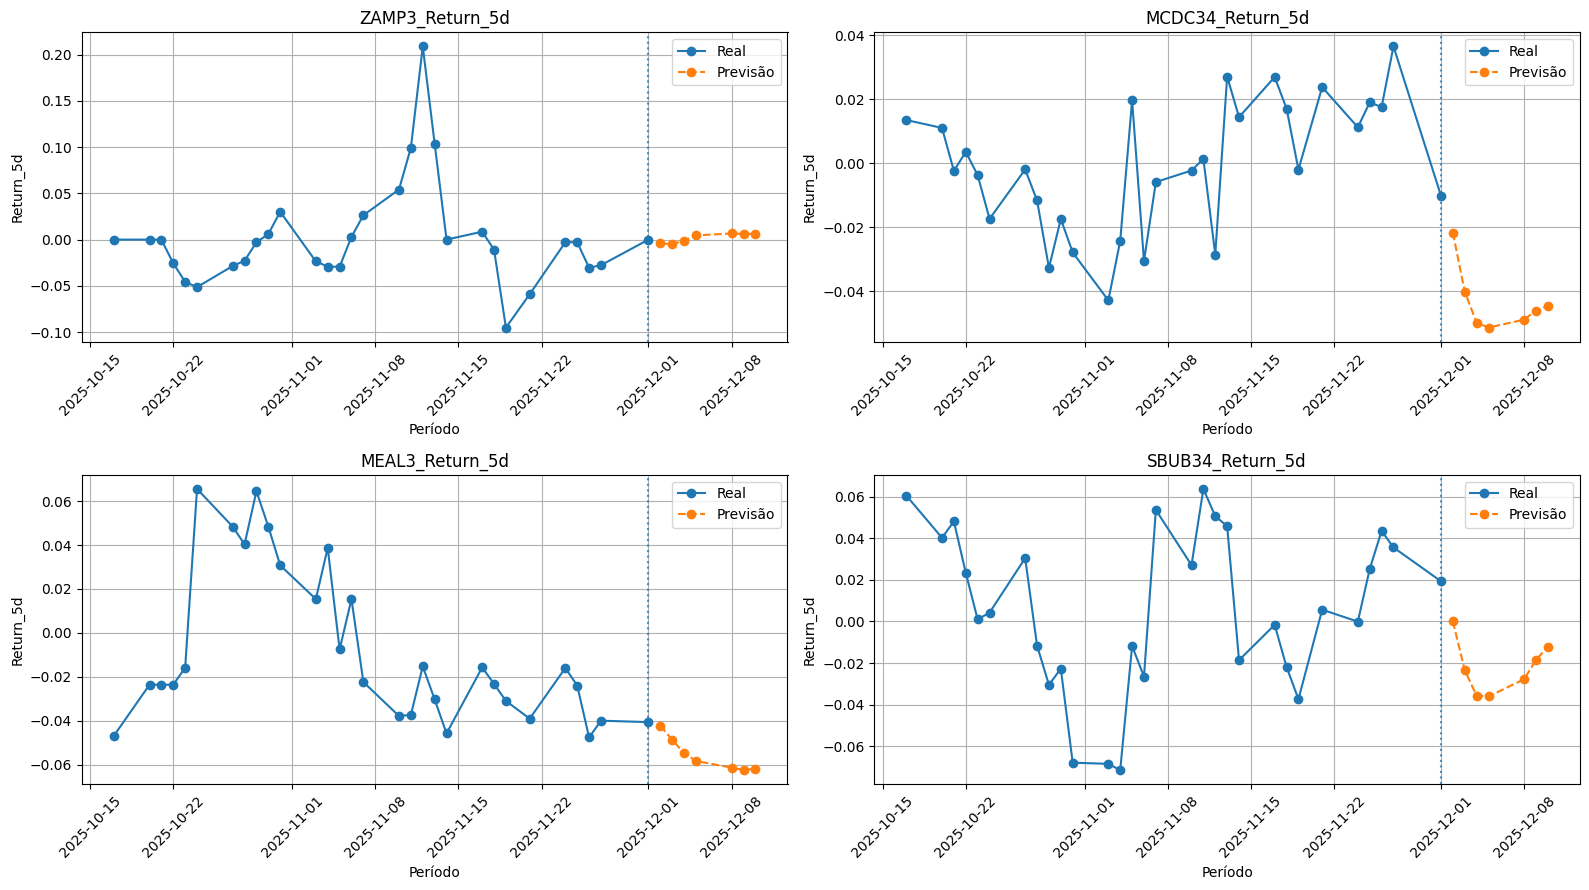

In [ ]:
# ==========================================
# HISTÓRICO REAL + PREVISÃO FUTURA
# PARA OS 4 ATIVOS
# ==========================================
model.eval()

n_future = 7
n_past = 30   # quantidade de pontos reais anteriores para mostrar
device = next(model.parameters()).device

target_cols = [
    'ZAMP3_Return_5d',
    'MCDC34_Return_5d',
    'MEAL3_Return_5d',
    'SBUB34_Return_5d'
]

target_idx = [data.columns.get_loc(col) for col in target_cols]

# ------------------------------------------
# 1. Última sequência para iniciar previsão
# ------------------------------------------
last_sequence = data.iloc[-seq_len:].copy().values
last_scaled = scaler.transform(last_sequence)

current_input = torch.tensor(
    last_scaled, dtype=torch.float32
).unsqueeze(0).to(device)

future_preds_scaled = []

# ------------------------------------------
# 2. Previsão recursiva multialvo
# ------------------------------------------
for _ in range(n_future):
    with torch.no_grad():
        next_pred = model(current_input)   # [1, 4]
        pred_vals = next_pred.detach().cpu().numpy().reshape(-1)

    future_preds_scaled.append(pred_vals)

    next_step = current_input[0, -1, :].detach().cpu().numpy().copy()

    for j, idx in enumerate(target_idx):
        next_step[idx] = pred_vals[j]

    next_step_tensor = torch.tensor(
        next_step, dtype=torch.float32
    ).unsqueeze(0).unsqueeze(1).to(device)

    current_input = torch.cat(
        [current_input[:, 1:, :], next_step_tensor],
        dim=1
    )

# ------------------------------------------
# 3. Inverter escala só dos targets
# ------------------------------------------
future_preds_scaled = np.array(future_preds_scaled)   # [n_future, 4]

future_full_scaled = np.zeros((n_future, scaler.n_features_in_))
future_full_scaled[:, target_idx] = future_preds_scaled

future_full_inverse = scaler.inverse_transform(future_full_scaled)
future_returns = future_full_inverse[:, target_idx]

future_df = pd.DataFrame(future_returns, columns=target_cols)

# ------------------------------------------
# 4. Datas futuras
# ------------------------------------------
if isinstance(data.index, pd.DatetimeIndex):
    last_date = data.index[-1]
    future_dates = pd.bdate_range(
        start=last_date + pd.Timedelta(days=1),
        periods=n_future
    )
else:
    future_dates = [f"Dia +{i}" for i in range(1, n_future + 1)]

future_df.index = future_dates

# ------------------------------------------
# 5. Histórico real anterior à previsão
# ------------------------------------------
past_df = data[target_cols].iloc[-n_past:].copy()

# ------------------------------------------
# 6. Plot: real + previsão no mesmo gráfico
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=False)

for i, ax in enumerate(axes.flatten()):
    col = target_cols[i]

    # histórico real
    ax.plot(
        past_df.index,
        past_df[col].values,
        label='Real',
        marker='o'
    )

    # previsão futura
    ax.plot(
        future_df.index,
        future_df[col].values,
        label='Previsão',
        marker='o',
        linestyle='--'
    )

    # linha separando passado e futuro
    if isinstance(data.index, pd.DatetimeIndex):
        ax.axvline(x=data.index[-1], linestyle=':', alpha=0.8)

    ax.set_title(col)
    ax.set_xlabel('Período')
    ax.set_ylabel('Return_5d')
    ax.grid(True)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;



&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;



# Síntese Final do Estudo

#Avaliação de estrutural do modelo
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 1 — Definição do objeto de estudo

O ponto de partida do projeto foi a definição do objeto de estudo. Em vez de trabalhar com um único ativo, o problema foi construído a partir de uma carteira com **4 ativos do setor de fast-food**: **ZAMP3, MCDC34, MEAL3 e SBUB34**. Essa escolha foi importante porque mostrou, desde o início, que a modelagem precisava considerar diferentes comportamentos dentro do mesmo setor, incluindo ativos locais e BDRs.

Essa decisão impactou diretamente a estrutura do modelo, porque o problema deixou de ser univariado e passou a ser **multivariado**. Por isso, a saída final foi definida com **`output_size = 4`**, permitindo prever simultaneamente um retorno para cada ativo analisado.

---


&nbsp;&nbsp;&nbsp;&nbsp;

##<Center>Passo 2 — Definição do que seria previsto

Depois de definir os ativos, foi necessário decidir qual variável o modelo deveria prever. O estudo inicial mostrou que usar apenas o **preço de fechamento** não era o mais adequado para o objetivo do trabalho, porque o interesse não era apenas saber o nível do preço, mas entender **movimento, direção e tendência**.

Por isso, o alvo escolhido foi o **`Return_5d`**, ou seja, o retorno acumulado em 5 dias. Essa escolha é coerente com a lógica do estudo exploratório, porque o retorno representa melhor a variação do ativo do que o preço bruto isolado. Assim, o modelo foi orientado para prever comportamento de mercado, e não apenas valor absoluto.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 3 — Definição dos passos de observação
&nbsp;&nbsp;&nbsp;&nbsp;

Com o alvo definido, entrou o primeiro parâmetro: os **passos de observação**. O valor escolhido foi **`seq_len = 7`**, o que significa que o modelo observa **7 períodos anteriores** antes de gerar a previsão.

A janela temporal escolhida foi de **`seq_len = 7`**, ou seja, cada amostra entrega ao modelo **7 períodos anteriores** antes da previsão. Essa escolha foi justificada no projeto pela ideia de preservar um **ciclo semanal completo**, o que faz sentido dentro do estudo do setor de fast-food, já que esse tipo de ativo pode refletir comportamento recorrente de consumo ao longo da semana. Então, a janela não foi arbitrária: ela tenta representar um contexto curto, mas completo o suficiente para capturar esse padrão recente.
&nbsp;&nbsp;&nbsp;&nbsp;


---
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 4 — Construção das features
&nbsp;&nbsp;&nbsp;&nbsp;

Depois disso, veio a etapa de engenharia de atributos. O modelo não foi alimentado apenas com preços, mas com um conjunto de variáveis que traduzem o comportamento dos ativos em diferentes dimensões.

Entre essas features estão:

- **`Return_1d`**
- **`Return_5d`**
- **`Volatility_10`**
- **`Range`**
- **`OC_Return`**
- **`Close_vs_SMA`**
- **`Close_vs_EMA`**
- **`Volume_Change`**

Essa etapa reflete diretamente o estudo anterior, porque a análise exploratória indicava que olhar somente para o fechamento seria insuficiente. O modelo precisava receber sinais que representassem não só preço, mas também **direção, intensidade, volatilidade, posição relativa e dinâmica de volume**. Assim, as features funcionam como a tradução numérica do que foi observado no estudo de objeto.
&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 5 — Normalização dos dados
&nbsp;&nbsp;&nbsp;&nbsp;

Com as features prontas, foi feita a normalização usando **`MinMaxScaler`**, que transformou as variáveis para a faixa entre **0 e 1**.

Essa etapa foi necessária porque as features têm escalas muito diferentes entre si. Preço, volume, retorno e indicadores técnicos não operam naturalmente na mesma magnitude. Sem normalização, algumas variáveis poderiam dominar o treinamento apenas por terem valores absolutos maiores. Portanto, essa escolha ajuda o modelo a aprender de forma mais equilibrada.
&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 6 — Definição das camadas do modelo

Depois da preparação dos dados, foi definida a arquitetura do modelo. Aqui aparece o segundo parâmetro exigido pelo professor: o número de **camadas**.

A arquitetura final foi composta por **2 camadas recorrentes principais**:

1. uma camada **LSTM**
2. seguida de uma camada **GRU**

Essa estrutura híbrida foi escolhida porque o problema envolve dependência temporal, múltiplos ativos e várias features por passo temporal. Duas camadas recorrentes permitem que o modelo faça uma leitura temporal em dois níveis: primeiro captando padrões mais ricos da sequência e depois reorganizando essa informação para a etapa final de previsão.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 7 — Definição do número de neurônios
&nbsp;&nbsp;&nbsp;&nbsp;

O terceiro parâmetro exigido pelo professor foi o número de **neurônios** por camada.

Os valores escolhidos foram:

- **`hidden_lstm = 64`**
- **`hidden_gru = 32`**

Isso significa que a primeira camada recorrente possui **64 neurônios**, enquanto a segunda possui **32 neurônios**.

Essa escolha pode ser explicada pela lógica de **Feature Learning guiado pela razão L/N**. Como o projeto trabalha com várias features, múltiplos ativos e sequências temporais, a rede precisava de capacidade suficiente para aprender padrões relevantes. Ao mesmo tempo, ela não poderia crescer demais em relação ao número de observações disponíveis, porque isso aumentaria o risco de sobreajuste. Por isso, a configuração **64 → 32** busca equilibrar capacidade de representação e controle da complexidade.
&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 8 — Relação entre passos, camadas e neurônios
&nbsp;&nbsp;&nbsp;&nbsp;

Considerando os três parâmetros mínimos exigidos no trabalho, a configuração final ficou assim:

- **Passos de observação:** `7`
- **Camadas recorrentes:** `2`
- **Neurônios:** `64` na LSTM e `32` na GRU

Esses três elementos não foram definidos separadamente. Eles formam um conjunto coerente. Os **7 passos** dão ao modelo contexto temporal recente; as **2 camadas** aumentam a profundidade da leitura sequencial; e os **64/32 neurônios** fornecem capacidade suficiente para aprender relações entre as features, sem tornar a arquitetura excessivamente complexa para o volume de dados disponível.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 9 — Ajuste da entrada e da saída do modelo

A quantidade de entradas foi definida dinamicamente como **`input_size = X_train.shape[2]`**, ou seja, de acordo com o número real de features geradas na etapa anterior.

Já a saída foi fixada em **`output_size = 4`**, porque o modelo precisava prever os retornos dos **4 ativos** ao mesmo tempo.

Essa parte mostra que a arquitetura foi montada para refletir exatamente a estrutura do problema: várias features por passo temporal na entrada e quatro previsões finais na saída.

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 10 — Definição da estratégia de treinamento

Depois da arquitetura pronta, foi definida a estratégia de treinamento. A base foi dividida em:

- **80% para treino**
- **20% para teste**

Essa divisão respeitou a ordem temporal dos dados, o que é fundamental em séries financeiras, já que o modelo deve aprender com o passado para prever o futuro.

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 11 — Definição dos hiperparâmetros de treinamento

Na etapa de treinamento, foram escolhidos os seguintes hiperparâmetros:

- **`batch_size = 32`**
- **`MSELoss`**
- **`Adam` com `learning_rate = 0.001`**
- **`30` épocas**

O **batch size 32** foi usado para equilibrar eficiência computacional e estabilidade no ajuste.  
A **MSELoss** foi escolhida porque o problema é de regressão multivariada, então faz sentido medir diretamente o erro entre os retornos previstos e os retornos reais.  
O **Adam com taxa 0.001** foi adotado por ser um otimizador estável para redes neurais recorrentes.  
As **30 épocas** permitiram treinar o modelo por várias passagens sobre os dados sem prolongar excessivamente o processo.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Passo 12 — Controle de generalização

Durante o treinamento, foi acompanhado o desempenho em treino e validação, com salvamento do **melhor modelo** com base na menor perda de validação.

Essa decisão faz sentido porque o estudo do problema já mostrava que séries financeiras possuem muito ruído. Portanto, não bastava usar a última época treinada; era mais adequado preservar a versão que demonstrasse melhor capacidade de generalização.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

##<center> Fechamento do pipeline

&nbsp;&nbsp;&nbsp;&nbsp;

Assim, o pipeline do projeto pode ser lido da seguinte forma:

1. **definição dos ativos**
2. **definição do alvo**
3. **escolha dos passos de observação**
4. **construção das features**
5. **normalização**
6. **definição das camadas**
7. **definição dos neurônios**
8. **ajuste da entrada e da saída**
9. **divisão treino/teste**
10. **definição dos hiperparâmetros**
11. **treinamento com controle de validação**



&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;



&nbsp;&nbsp;&nbsp;&nbsp;


&nbsp;&nbsp;&nbsp;&nbsp;

&nbsp;&nbsp;&nbsp;&nbsp;




# Avaliação de desempenho do modelo
&nbsp;&nbsp;&nbsp;&nbsp;

###<center> Passo 13 — Estrutura final avaliada
&nbsp;&nbsp;&nbsp;&nbsp;

Ao final da etapa de treinamento, o modelo avaliado foi uma arquitetura híbrida composta por:

- **Entrada:** `90` features por passo temporal
- **Janela temporal:** `7` passos de observação
- **Camadas recorrentes:** `2`
- **LSTM:** `64` neurônios
- **GRU:** `32` neurônios
- **Saída:** `4` alvos simultâneos

A estrutura final ficou, portanto, com entrada de dimensão **(7, 90)** para cada amostra e saída com **4 previsões**, uma para cada ativo: **ZAMP3, MCDC34, MEAL3 e SBUB34**. Isso confirma que o problema foi tratado como uma **regressão multivariada sequencial**, coerente com a proposta inicial do projeto.

&nbsp;&nbsp;&nbsp;&nbsp;

---

&nbsp;&nbsp;&nbsp;&nbsp;

###<center> Passo 14 — Volume de dados utilizado
&nbsp;&nbsp;&nbsp;&nbsp;

O conjunto final foi dividido da seguinte forma:

- **X_train:** `(1240, 7, 90)`
- **y_train:** `(1240, 4)`
- **X_test:** `(310, 7, 90)`
- **y_test:** `(310, 4)`

Esses números mostram que o modelo foi treinado com **1240 sequências temporais** e avaliado em **310 sequências de teste**, cada uma contendo **7 períodos anteriores** e **90 features por período**. Isso reforça a ideia de que a rede não recebeu uma entrada simples, mas sim uma estrutura relativamente rica, com múltiplas variáveis por ativo e dependência temporal explícita.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

###<center> Passo 15 — Comportamento do treinamento
&nbsp;&nbsp;&nbsp;&nbsp;

As curvas de perda mostram que o treinamento foi consistente ao longo das **30 épocas**.

- **Train Loss inicial:** `0.035983`
- **Val Loss inicial:** `0.005886`
- **Train Loss final:** `0.002507`
- **Val Loss final:** `0.002416`

&nbsp;&nbsp;&nbsp;&nbsp;


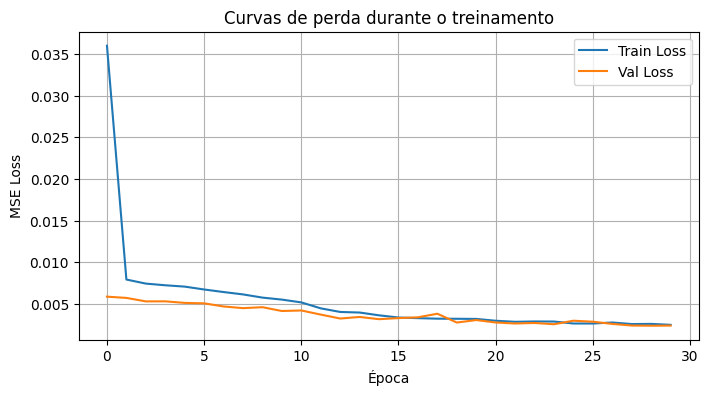

&nbsp;&nbsp;&nbsp;&nbsp;


O primeiro ponto relevante é que houve uma **queda forte logo nas primeiras épocas**, indicando que o modelo conseguiu aprender rapidamente os padrões mais gerais dos dados. Depois disso, a redução das perdas continuou de forma mais gradual, o que é esperado à medida que o ajuste fica mais fino.

Outro ponto importante é que a **validação acompanhou o treino sem divergência acentuada**. Isso sugere que o modelo não apresentou um sobreajuste severo durante o processo. Mesmo com pequenas oscilações intermediárias, a tendência geral foi de convergência, e a diferença entre perda de treino e perda de validação permaneceu relativamente controlada.

Em termos interpretativos, isso indica que a arquitetura escolhida — com **2 camadas recorrentes** e **64/32 neurônios** — teve capacidade suficiente para aprender padrões relevantes, mas sem crescer a ponto de comprometer a generalização de forma evidente.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

###<center> Passo 16 — Desempenho no conjunto de teste
&nbsp;&nbsp;&nbsp;&nbsp;

No conjunto de teste, o modelo apresentou o seguinte desempenho:

#### ZAMP3
- **MAE:** `0.032828`
- **RMSE:** `0.046157`
- **R²:** `0.5947`
- **Acurácia direcional:** `67.42%`

#### MCDC34
- **MAE:** `0.016481`
- **RMSE:** `0.02094`
- **R²:** `0.3476`
- **Acurácia direcional:** `72.26%`

#### MEAL3
- **MAE:** `0.029099`
- **RMSE:** `0.03857`
- **R²:** `0.5688`
- **Acurácia direcional:** `72.58%`

#### SBUB34
- **MAE:** `0.019766`
- **RMSE:** `0.02628`
- **R²:** `0.6026`
- **Acurácia direcional:** `78.71%`

De forma geral, os resultados mostram que o modelo teve desempenho **bom a moderado**, com melhor capacidade explicativa em **SBUB34** e **ZAMP3**, desempenho também sólido em **MEAL3**, e um resultado mais limitado em **MCDC34**.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

###<center> Passo 17 — Interpretação dos indicadores
&nbsp;&nbsp;&nbsp;&nbsp;

A leitura conjunta dos indicadores ajuda a entender melhor o comportamento do modelo.

O **MAE** e o **RMSE** mostram que os erros absolutos ficaram relativamente contidos, especialmente em **MCDC34** e **SBUB34**, que apresentaram menores magnitudes de erro. Já **ZAMP3** e **MEAL3** tiveram erros maiores, o que é compatível com séries mais intensas ou mais difíceis de ajustar.

O **R²** mostra o quanto o modelo conseguiu explicar da variação observada em cada ativo. Nesse ponto:

- **SBUB34 (`0.6026`)** teve o melhor ajuste geral;
- **ZAMP3 (`0.5947`)** ficou muito próximo;
- **MEAL3 (`0.5688`)** também apresentou resultado forte;
- **MCDC34 (`0.3476`)** teve poder explicativo mais baixo, indicando que esse ativo foi o mais difícil de modelar entre os quatro.

Já a **acurácia direcional** foi alta em todos os casos, variando de **67.42% a 78.71%**. Isso é especialmente relevante para o objetivo do trabalho, porque mostra que o modelo frequentemente acerta a **direção do movimento**, mesmo quando não reproduz perfeitamente a magnitude do retorno. Como o projeto foi orientado para tendência e comportamento de mercado, esse é um resultado importante.

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

### Passo 18 — Leitura dos gráficos de previsão

Os gráficos comparando valores reais e previstos mostram que o modelo conseguiu acompanhar razoavelmente bem o formato geral das séries, principalmente nos movimentos mais estruturais. Em vários trechos, a curva prevista segue a direção da curva real, o que está alinhado com a boa acurácia direcional observada nas métricas.

Ao mesmo tempo, também fica visível que o modelo tende a **suavizar alguns picos e vales mais extremos**. Isso é comum em problemas de regressão com séries financeiras, porque movimentos muito bruscos são mais difíceis de antecipar e costumam carregar maior componente de ruído. Portanto, o modelo parece funcionar melhor para capturar o **comportamento geral** da série do que para reproduzir perfeitamente oscilações muito abruptas.

Essa leitura é coerente com o que aparece nas métricas: bons resultados em direção e ajuste geral razoável, mas com limitações naturais na previsão exata da intensidade dos movimentos mais extremos.

&nbsp;&nbsp;&nbsp;&nbsp;

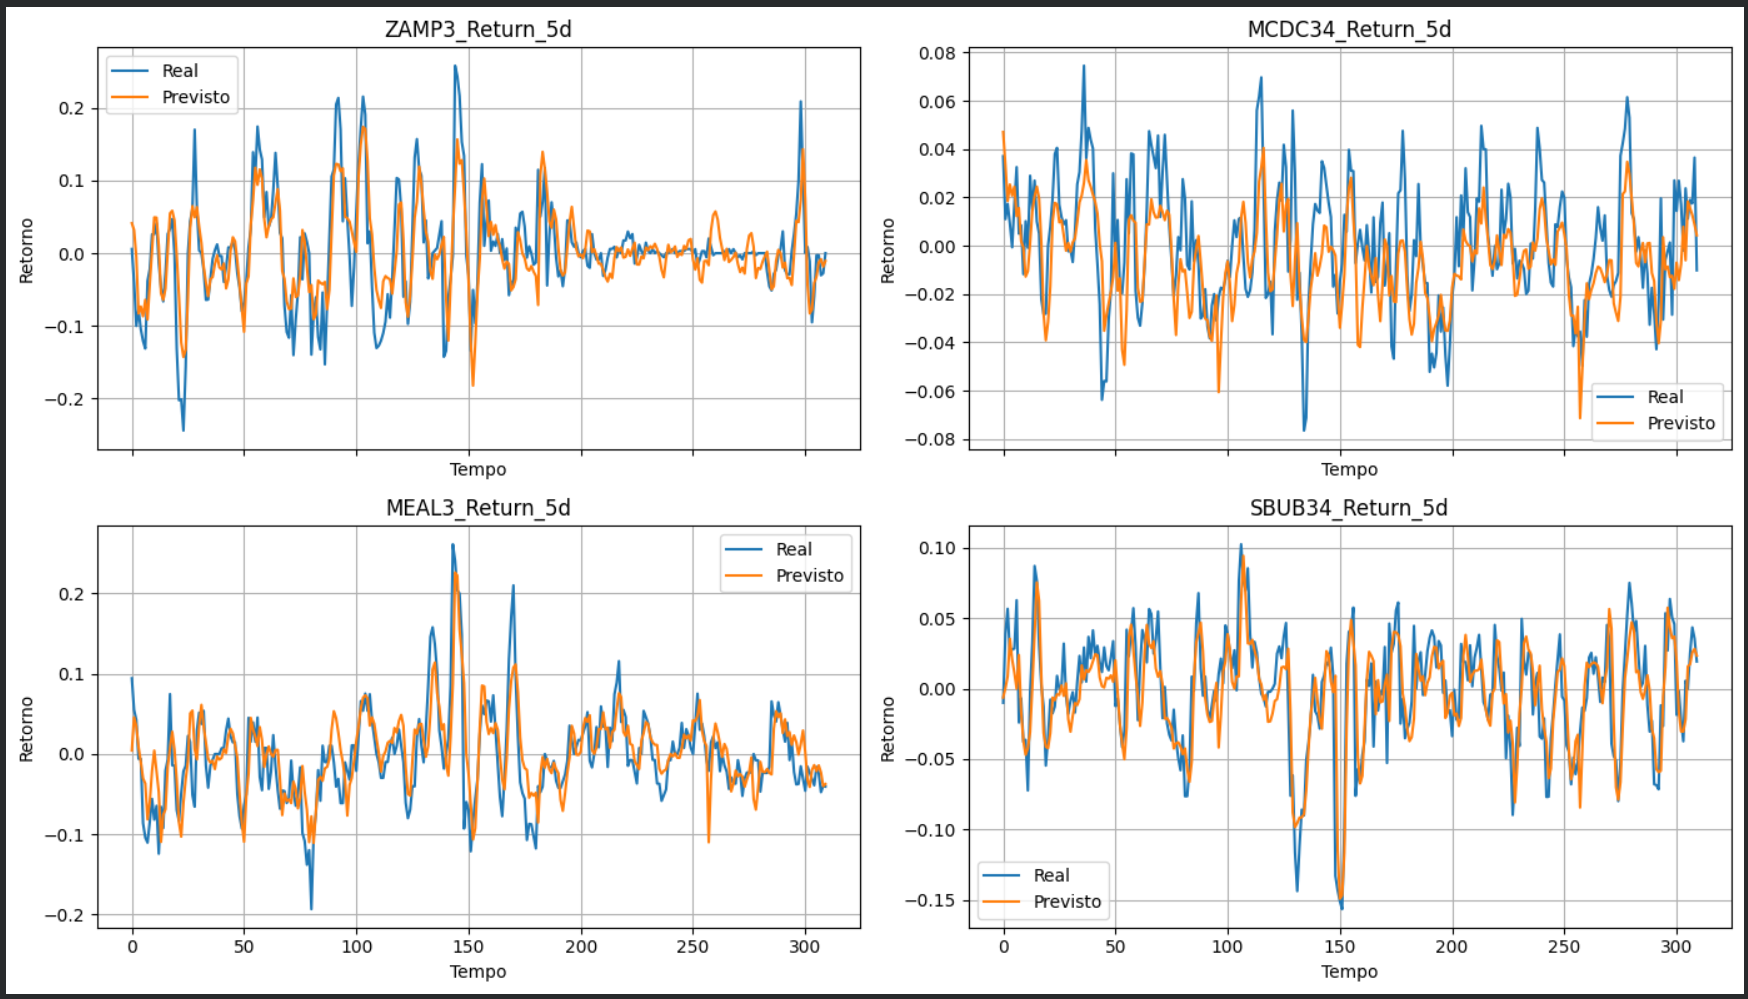

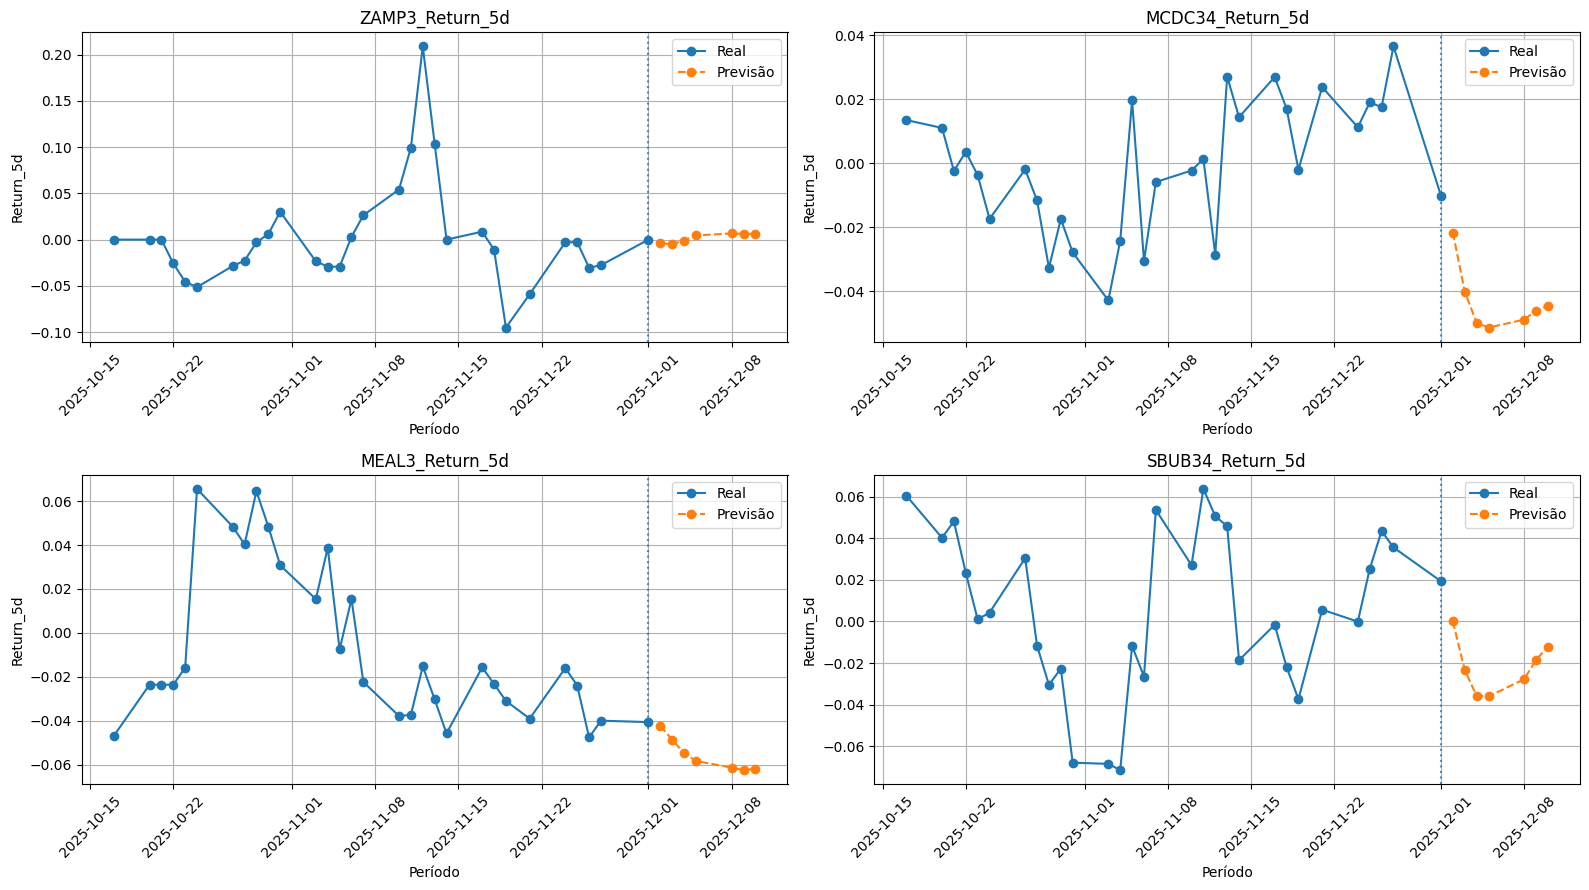

&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;

###<center> Passo 19 — Relação entre desempenho e escolhas do pipeline
&nbsp;&nbsp;&nbsp;&nbsp;

A avaliação final mostra que as escolhas feitas ao longo do pipeline foram coerentes com o problema estudado.

&nbsp;&nbsp;&nbsp;&nbsp;

A combinação de:

- **7 passos de observação**
- **90 features por sequência**
- **2 camadas recorrentes**
- **64 neurônios na LSTM**
- **32 neurônios na GRU**
- **saída multivariada para 4 ativos**

&nbsp;&nbsp;&nbsp;&nbsp;

foi suficiente para produzir um modelo com capacidade real de aprendizado e generalização. O desempenho obtido indica que a arquitetura conseguiu extrair informação útil do conjunto de variáveis construído a partir do estudo exploratório, especialmente no que se refere à direção dos movimentos.

Isso reforça a ligação entre o estudo de objeto e a modelagem: como o problema foi tratado desde o início como temporal, multivariado e orientado para retorno, a avaliação final mostra que o modelo respondeu de forma compatível com essas escolhas.
&nbsp;&nbsp;&nbsp;&nbsp;

---
&nbsp;&nbsp;&nbsp;&nbsp;



# Conclusão do estudo

De forma geral, o modelo pode ser considerado **bem-sucedido dentro da proposta do projeto**. Ele apresentou:

- **convergência estável no treinamento**;
- **boa capacidade de generalização**;
- **R² moderado a bom em 3 dos 4 ativos**;
- **acurácia direcional alta em todos os ativos**;
- **capacidade de acompanhar a dinâmica geral das séries**, embora com suavização de oscilações extremas.

Assim, a avaliação final sugere que o modelo não apenas aprendeu padrões presentes nos dados, mas conseguiu transformar o estudo exploratório em previsões úteis, sobretudo para interpretar **direção e comportamento dos retornos**, que era justamente o foco central do trabalho.